# This notebook compares all models

First check csv file of current diffusion has correct column names, if not replace with the following:


Scenario_ID,Month,Y_1M,Y_3M,Y_6M,Y_1Y,Y_2Y,Y_3Y,Y_5Y,Y_7Y,Y_10Y,Y_20Y,Y_30Y


# datasets inladen

In [19]:
import pandas as pd
import numpy as np

# ─────────────────────────────────────────────
# Dataset paths
# ─────────────────────────────────────────────
historical_data   = "historical data train.csv"
current_diffusion = "diffusion 23-4.csv" #"mvp1 18-4.csv"
hjm_data          = "hjm_pca_scenarios monthly basis 24-4.csv"
cann_data         = "cann 21-4 v3 monthly.csv"
VAE_data          = "vae_scenarios_no_date.csv"

# All generated scenario files are capped at 200 scenarios
N_SCENARIOS = 200

def load_scenarios(path, n_scen=N_SCENARIOS):
    """
    Load a generated-scenario csv (Scenario_ID, Month, Y_1M … Y_30Y)
    and keep the first `n_scen` scenarios.
    """
    df = pd.read_csv(path)
    keep_ids = df["Scenario_ID"].unique()[:n_scen]
    return df[df["Scenario_ID"].isin(keep_ids)].reset_index(drop=True)

# Registry of every generative model — used by the comparison loops further down
MODELS = {
    "Diffusion": current_diffusion,
    "HJM-PCA":   hjm_data,
    "CANN":      cann_data,
    "VAE":       VAE_data,
}


# Visualising and preparing Historical Data
- We visualise NS factors and volatility trough time
- We preprosess the historical data: transform to monthly data and create rolling windows of 5 years shifting each month

## Visualising historical data

### NS historical data

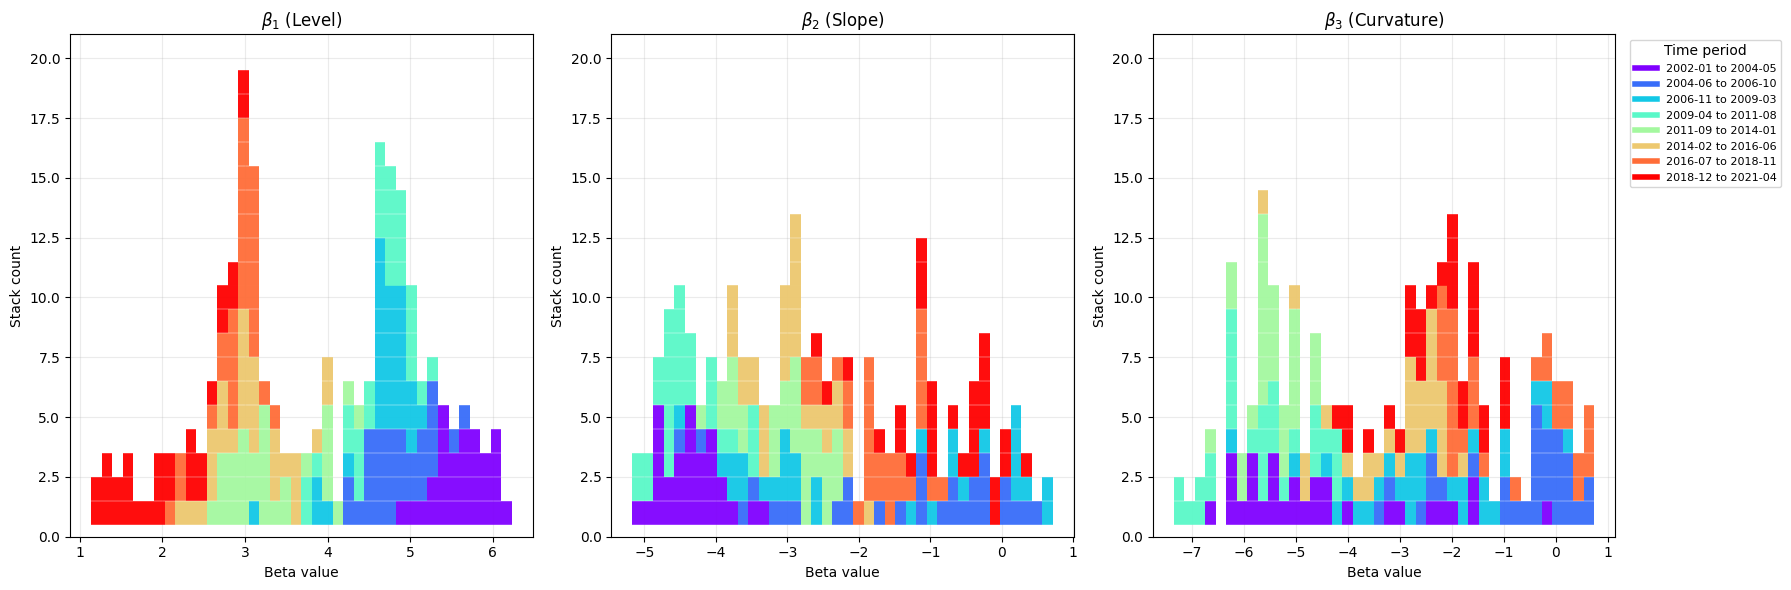

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Nelson-Siegel setup ─────────────────────────────────────────────────────
LAMBDA = 0.0609

HIST_MATS_YR = np.array([1/12, 3/12, 6/12, 1, 2, 3, 5, 7, 10, 20, 30])
HIST_MATS_MO = HIST_MATS_YR * 12

def ns_loadings(tau, lam):
    lt = lam * tau
    L1 = np.ones_like(lt)
    L2 = (1 - np.exp(-lt)) / lt
    L3 = L2 - np.exp(-lt)
    return np.column_stack([L1, L2, L3])

def fit_ns_ols(yields, tau, lam):
    X = ns_loadings(tau, lam)
    betas, _, _, _ = np.linalg.lstsq(X, yields, rcond=None)
    return betas

# ── Load data ───────────────────────────────────────────────────────────────
historical_data = historical_data

hist_cols = ['Yield_1M', 'Yield_3M', 'Yield_6M', 'Yield_1Y', 'Yield_2Y',
             'Yield_3Y', 'Yield_5Y', 'Yield_7Y', 'Yield_10Y', 'Yield_20Y', 'Yield_30Y']

hist = pd.read_csv(historical_data, parse_dates=['DATE'])
hist = hist.set_index('DATE')[hist_cols]
hist_monthly = hist.resample('ME').last().dropna()

# ── Fit NS ──────────────────────────────────────────────────────────────────
hist_betas = np.array([
    fit_ns_ols(row.values, HIST_MATS_MO, LAMBDA)
    for _, row in hist_monthly.iterrows()
])

dates = hist_monthly.index
n_obs = len(dates)

beta_labels = [
    r'$\beta_1$ (Level)',
    r'$\beta_2$ (Slope)',
    r'$\beta_3$ (Curvature)'
]

# ── Time coloring ───────────────────────────────────────────────────────────
n_periods = 8
period_edges = np.linspace(0, n_obs, n_periods + 1, dtype=int)
period_ids = np.zeros(n_obs, dtype=int)

for p in range(n_periods):
    period_ids[period_edges[p]:period_edges[p+1]] = p

colors = plt.cm.rainbow(np.linspace(0, 1, n_periods))

period_labels = []
for p in range(n_periods):
    start = dates[period_edges[p]]
    end = dates[period_edges[p+1]-1]
    period_labels.append(f"{start.strftime('%Y-%m')} to {end.strftime('%Y-%m')}")

# ── Compute GLOBAL Y max only ────────────────────────────────────────────────
n_bins = 40
global_max_stack = 0

for i in range(3):
    vals = hist_betas[:, i]
    
    # IMPORTANT: each plot keeps its own x-range → use local binning
    vmin, vmax = vals.min(), vals.max()
    bin_edges = np.linspace(vmin, vmax, n_bins + 1)
    
    bin_idx = np.digitize(vals, bin_edges) - 1
    bin_idx = np.clip(bin_idx, 0, n_bins - 1)

    for b in range(n_bins):
        count = np.sum(bin_idx == b)
        global_max_stack = max(global_max_stack, count)

# ── Plot function ───────────────────────────────────────────────────────────
def stacked_bin_bars(ax, values, period_ids, colors, ymax):
    vmin, vmax = values.min(), values.max()
    bin_edges = np.linspace(vmin, vmax, n_bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_width = bin_edges[1] - bin_edges[0]

    bin_idx = np.digitize(values, bin_edges) - 1
    bin_idx = np.clip(bin_idx, 0, n_bins - 1)

    for b in range(n_bins):
        idx = np.where(bin_idx == b)[0]
        if len(idx) == 0:
            continue

        idx = idx[np.argsort(idx)]

        for stack_level, obs_idx in enumerate(idx, start=1):
            x_center = bin_centers[b]

            ax.hlines(
                y=stack_level,
                xmin=x_center - 0.5 * bin_width,
                xmax=x_center + 0.5 * bin_width,
                color=colors[period_ids[obs_idx]],
                linewidth=17,
                alpha=0.95
            )

    ax.set_ylim(0, ymax)
    ax.set_ylabel("Stack count")
    ax.grid(True, alpha=0.25)

# ── Plot ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, ax in enumerate(axes):
    stacked_bin_bars(
        ax=ax,
        values=hist_betas[:, i],
        period_ids=period_ids,
        colors=colors,
        ymax=global_max_stack + 2
    )
    ax.set_title(beta_labels[i])
    ax.set_xlabel("Beta value")

# Legend
handles = [plt.Line2D([0], [0], color=colors[p], lw=4) for p in range(n_periods)]
axes[2].legend(handles, period_labels, title="Time period",
               loc='upper left', bbox_to_anchor=(1.02, 1.0), fontsize=8)

plt.tight_layout()
plt.show()

### historical data volatility

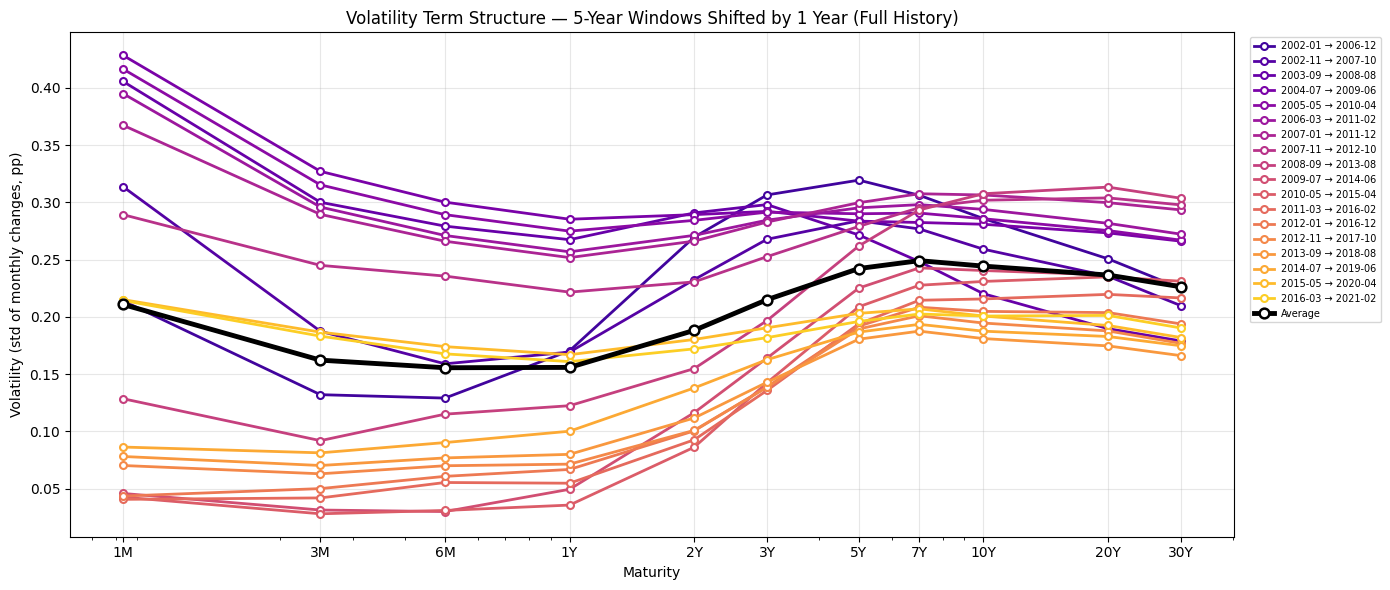

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(historical_data)
df["DATE"] = pd.to_datetime(df["DATE"])
df = df.set_index("DATE").sort_index()

yield_cols     = [c for c in df.columns if c.startswith("Yield_")]
maturities     = [c.replace("Yield_", "") for c in yield_cols]
maturity_years = [1/12, 3/12, 6/12, 1, 2, 3, 5, 7, 10, 20, 30]

yields_monthly = df[yield_cols].resample("ME").last()

WINDOW = 60   # 5 years
STEP   = 10   # shift by 1 year

windows = []
for start in range(0, len(yields_monthly) - WINDOW + 1, STEP):
    window = yields_monthly.iloc[start : start + WINDOW]
    label  = f"{window.index[0].strftime('%Y-%m')} → {window.index[-1].strftime('%Y-%m')}"
    windows.append((label, window))

colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(windows)))

fig, ax = plt.subplots(figsize=(14, 6))
all_vol_values = []

for (label, window), color in zip(windows, colors):
    vol        = window.diff().dropna().std()
    vol_values = [vol[col] for col in yield_cols]
    all_vol_values.append(vol_values)
    ax.plot(maturity_years, vol_values, color=color, linewidth=2,
            marker="o", markersize=5, markerfacecolor="white",
            markeredgewidth=1.5, label=label)

# Black average curve on top
all_vol_values = np.array(all_vol_values)
avg_vol_values = all_vol_values.mean(axis=0)
ax.plot(maturity_years, avg_vol_values,
        color="black", linewidth=3.5,
        marker="o", markersize=7,
        markerfacecolor="white", markeredgecolor="black", markeredgewidth=1.8,
        label="Average")

ax.set_xscale("log")
ax.set_xticks(maturity_years)
ax.set_xticklabels(maturities)
ax.set_xlabel("Maturity")
ax.set_ylabel("Volatility (std of monthly changes, pp)")
ax.set_title("Volatility Term Structure — 5-Year Windows Shifted by 1 Year (Full History)")
ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left")
ax.grid(alpha=0.3)

plt.tight_layout()
#plt.savefig("volatility_all_windows.png", dpi=150, bbox_inches="tight")
plt.show()

## Preprossessing historical data

In [22]:
# ─────────────────────────────────────────────
# Historical-data preparation
# ─────────────────────────────────────────────
# The historical CSV contains daily observations of the yield curve plus three
# macro columns (FedFunds, CPI_Level, Real_GDP). For the evaluation we need:
#   1. daily → monthly data (end-of-month value)
#   2. drop the three macro columns so only the yield curve remains
#   3. build rolling windows of 60 timesteps, shifting by 1 month each time
#      (comparable to the 60-month generated scenarios)
#
# `prepare_historical_data` is the single entry point used everywhere in this
# notebook whenever we need the monthly historical data or rolling windows.

HIST_YIELD_COLS = [
    "Yield_1M", "Yield_3M", "Yield_6M", "Yield_1Y", "Yield_2Y",
    "Yield_3Y", "Yield_5Y", "Yield_7Y", "Yield_10Y", "Yield_20Y", "Yield_30Y",
]
MACRO_COLS   = ["FedFunds", "CPI_Level", "Real_GDP"]
WINDOW_SIZE  = 60     # rolling window length (months) — matches scenario horizon
WINDOW_STEP  = 1      # shift by 1 month (rolling, not tumbling)


def prepare_historical_data(path=historical_data,
                            window=WINDOW_SIZE,
                            step=WINDOW_STEP):
    """
    Transform the raw historical CSV into the objects used by every
    evaluation section.

    Steps
    -----
    1. Parse DATE, sort, set as index.
    2. Resample daily → monthly (end-of-month) keeping the last observation
       of every month.
    3. Drop the three macro columns (FedFunds, CPI_Level, Real_GDP); only
       the 11 yield-curve columns remain.
    4. Build rolling windows of `window` months shifted by `step` months.

    Returns
    -------
    hist_monthly : pd.DataFrame
        (n_months, 11) — monthly yield curve, indexed by month-end DATE.
    hist_windows : np.ndarray
        (n_windows, window, 11) — rolling windows of the monthly data.
    """
    # 1. load
    df = pd.read_csv(path, parse_dates=["DATE"])
    df = df.set_index("DATE").sort_index()

    # 2. daily → monthly (end-of-month: last observation per month)
    monthly = df.resample("ME").last()

    # 3. drop the three macro columns — keep only the yield curve
    monthly = monthly.drop(columns=MACRO_COLS, errors="ignore")
    monthly = monthly[HIST_YIELD_COLS].dropna()

    # 4. rolling windows of `window` months, shift = `step`
    arr = monthly.values                 # (n_months, 11)
    n   = len(arr)
    if n < window:
        raise ValueError(f"Only {n} monthly observations; need at least {window}.")
    windows = np.stack([arr[s:s + window]
                        for s in range(0, n - window + 1, step)])
    return monthly, windows


# Run once and expose the results as module-level globals so every downstream
# cell can reuse them without re-loading or re-resampling the raw csv.
hist_monthly, hist_windows = prepare_historical_data()

print(f"Historical monthly observations : {hist_monthly.shape[0]}  "
      f"({hist_monthly.index[0].strftime('%Y-%m')} → "
      f"{hist_monthly.index[-1].strftime('%Y-%m')})")
print(f"Columns retained                : {list(hist_monthly.columns)}")
print(f"Rolling windows (60m, step 1)   : {hist_windows.shape}  "
      f"(n_windows, window, n_maturities)")


Historical monthly observations : 232  (2002-01 → 2021-04)
Columns retained                : ['Yield_1M', 'Yield_3M', 'Yield_6M', 'Yield_1Y', 'Yield_2Y', 'Yield_3Y', 'Yield_5Y', 'Yield_7Y', 'Yield_10Y', 'Yield_20Y', 'Yield_30Y']
Rolling windows (60m, step 1)   : (173, 60, 11)  (n_windows, window, n_maturities)


# Comparing models

## volatility

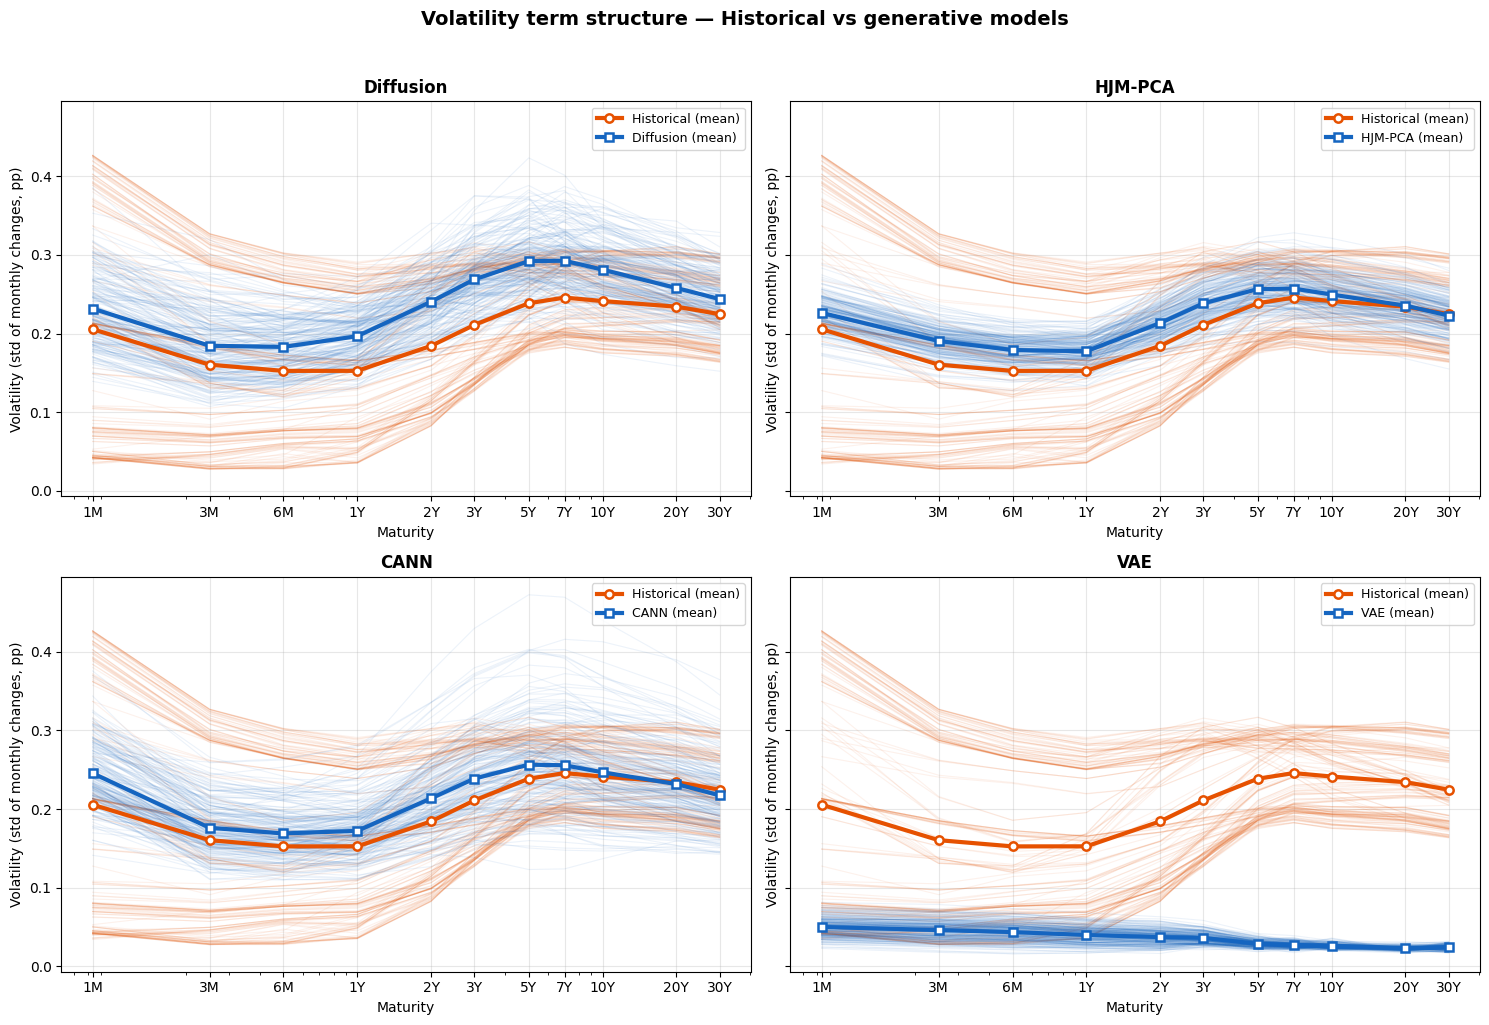

In [23]:
# ─────────────────────────────────────────────
# Volatility term structure — Historical vs every generative model
# ─────────────────────────────────────────────
# For every 60-month rolling window (historical) and every scenario (simulated)
# we compute the volatility curve: std of monthly changes per maturity.
# This is the same object, just coming from a different source — so the
# historical hist_windows and the simulated scenarios are directly comparable.
import matplotlib.pyplot as plt

SIM_YIELD_COLS = ["Y_1M","Y_3M","Y_6M","Y_1Y","Y_2Y",
                  "Y_3Y","Y_5Y","Y_7Y","Y_10Y","Y_20Y","Y_30Y"]
MATURITY_LABELS = ["1M","3M","6M","1Y","2Y","3Y","5Y","7Y","10Y","20Y","30Y"]
MATURITY_YEARS  = np.array([1/12, 3/12, 6/12, 1, 2, 3, 5, 7, 10, 20, 30])


def vol_curve(arr):
    """
    Volatility curve per maturity: std of monthly changes.
    Accepts (T, M) for a single path, or (N, T, M) for a batch of N paths.
    Returns (M,) or (N, M).
    """
    return np.diff(arr, axis=-2).std(axis=-2)


def scenario_tensor(path):
    """
    Load a scenario csv and reshape into (n_scenarios, n_months, n_maturities).
    """
    df = load_scenarios(path)
    sids = sorted(df["Scenario_ID"].unique())
    return np.stack([df[df["Scenario_ID"] == s]
                       .sort_values("Month")[SIM_YIELD_COLS]
                       .values
                     for s in sids])


# Historical volatility curves — one per 60-month rolling window
hist_vol_curves = vol_curve(hist_windows)           # (n_windows, 11)
hist_vol_mean   = hist_vol_curves.mean(axis=0)      # (11,)

# Simulated volatility curves — one per scenario, per model
sim_vol_curves = {name: vol_curve(scenario_tensor(path))
                  for name, path in MODELS.items()}


# ─────────────────────────────────────────────
# Plot: 2×2 grid, one panel per model
# ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharey=True)
fig.suptitle("Volatility term structure — Historical vs generative models",
             fontsize=14, fontweight="bold", y=1.02)

HIST_C   = "#E65100"    # orange
SIM_C    = "#1565C0"    # blue

for ax, (name, curves) in zip(axes.flat, sim_vol_curves.items()):
    # thin lines = individual paths
    for v in hist_vol_curves:
        ax.plot(MATURITY_YEARS, v, color=HIST_C, alpha=0.08, lw=0.8)
    for v in curves:
        ax.plot(MATURITY_YEARS, v, color=SIM_C,  alpha=0.08, lw=0.8)

    # mean curves
    ax.plot(MATURITY_YEARS, hist_vol_mean, color=HIST_C, lw=3,
            marker="o", markersize=6, markerfacecolor="white",
            markeredgewidth=1.8, label="Historical (mean)")
    ax.plot(MATURITY_YEARS, curves.mean(axis=0), color=SIM_C, lw=3,
            marker="s", markersize=6, markerfacecolor="white",
            markeredgewidth=1.8, label=f"{name} (mean)")

    ax.set_xscale("log")
    ax.set_xticks(MATURITY_YEARS)
    ax.set_xticklabels(MATURITY_LABELS)
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Maturity")
    ax.set_ylabel("Volatility (std of monthly changes, pp)")
    ax.grid(alpha=0.3)
    ax.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()


### Mean curve error
For each model we compute the per-scenario squared deviation between the simulated and mean historical volatility curve, then aggregate across the 200 scenarios.

In [24]:
# ─────────────────────────────────────────────
# Mean curve error
# ─────────────────────────────────────────────
# For each scenario i and model m the deviation between the simulated and
# mean-historical volatility curve is
#         E_i^curve = (1/M) * Σ_m (σ_i,m - σ_m^hist)²
# These per-scenario errors are then aggregated to a mean and a median across
# the 200 scenarios of each model.

curve_error_rows = []
for name, curves in sim_vol_curves.items():
    per_scen = ((curves - hist_vol_mean[None, :]) ** 2).mean(axis=1)
    curve_error_rows.append({
        "Model":            name,
        "Mean E_curve":     per_scen.mean(),
        "Median E_curve":   np.median(per_scen),
        "Std E_curve":      per_scen.std(),
        "Min E_curve":      per_scen.min(),
        "Max E_curve":      per_scen.max(),
    })

curve_error_df = pd.DataFrame(curve_error_rows).set_index("Model")

print("Mean curve error — lower is better")
print("=" * 70)
print(curve_error_df.round(5).to_string())


Mean curve error — lower is better
           Mean E_curve  Median E_curve  Std E_curve  Min E_curve  Max E_curve
Model                                                                         
Diffusion         0.003           0.003        0.002        0.000        0.010
HJM-PCA           0.001           0.001        0.001        0.000        0.004
CANN              0.002           0.001        0.003        0.000        0.026
VAE               0.031           0.031        0.002        0.025        0.035


### Volatility distribution analysis (short vs long maturities)
Short-term maturity is the 1-month rate; long-term is the average of the 10Y, 20Y and 30Y rates. Rolling windows of 1-year and 5-year are used to build the distribution of volatility estimates for each model and the historical data. The distributions are compared via mean, spread (P95 - P5), Wasserstein distance, extreme-volatility-frequency (EVF) error, skewness and kurtosis.

In [25]:
# ─────────────────────────────────────────────
# Volatility distribution — short (1M) vs long (avg 10Y/20Y/30Y) maturities
# ─────────────────────────────────────────────
# Using 1-year and 5-year rolling windows on monthly yield changes we obtain,
# for each model and for the historical data, a distribution of volatility
# estimates. The distributions are then compared along:
#   • mean and spread (P95 - P5)
#   • Wasserstein distance (overall shape match)
#   • EVF Error   = |p_sim - p_hist| where p is the proportion of obs. above
#                  the historical 95th percentile (extreme volatility freq.)
#   • skewness and kurtosis (descriptive, tail shape)
from scipy.stats import wasserstein_distance, skew, kurtosis

SHORT_HIST = "Yield_1M"
LONG_HIST  = ["Yield_10Y", "Yield_20Y", "Yield_30Y"]
SHORT_SIM  = "Y_1M"
LONG_SIM   = ["Y_10Y", "Y_20Y", "Y_30Y"]


def rolling_vol(series, window):
    """Rolling-window std of first differences; falls back to full-series std
    when the series is too short for the requested window."""
    diffs = series.diff().dropna()
    if window <= len(diffs):
        return diffs.rolling(window).std().dropna().values
    return np.array([diffs.std()])


def hist_vol_dist(cols, window):
    series = hist_monthly[cols].mean(axis=1) if isinstance(cols, list) else hist_monthly[cols]
    return rolling_vol(series, window)


def sim_vol_dist(path, cols, window):
    df = load_scenarios(path)
    out = []
    for _, g in df.groupby("Scenario_ID"):
        g = g.sort_values("Month")
        series = g[cols].mean(axis=1) if isinstance(cols, list) else g[cols]
        out.append(rolling_vol(series, window))
    return np.concatenate(out)


# ─────────────────────────────────────────────
# Compute distributions for each (window, maturity-segment, model)
# ─────────────────────────────────────────────
dist_rows = []
for window_label, window in [("1Y", 12), ("5Y", 60)]:
    for seg_label, hcols, scols in [
        ("Short (1M)",                SHORT_HIST, SHORT_SIM),
        ("Long (avg 10Y/20Y/30Y)",    LONG_HIST,  LONG_SIM),
    ]:
        h = hist_vol_dist(hcols, window)
        h_p95   = np.percentile(h, 95)
        h_mean  = h.mean()
        h_spread = np.percentile(h, 95) - np.percentile(h, 5)
        p_hist  = (h > h_p95).mean()

        # historical reference row
        dist_rows.append({
            "Window":     window_label,
            "Maturity":   seg_label,
            "Model":      "Historical",
            "Mean":       h_mean,
            "Spread":     h_spread,
            "Wasserstein": 0.0,
            "EVF Error":  0.0,
            "Skew":       skew(h),
            "Kurt":       kurtosis(h),
        })

        for name, path in MODELS.items():
            s = sim_vol_dist(path, scols, window)
            p_sim = (s > h_p95).mean()
            dist_rows.append({
                "Window":     window_label,
                "Maturity":   seg_label,
                "Model":      name,
                "Mean":       s.mean(),
                "Spread":     np.percentile(s, 95) - np.percentile(s, 5),
                "Wasserstein": wasserstein_distance(h, s),
                "EVF Error":  abs(p_sim - p_hist),
                "Skew":       skew(s),
                "Kurt":       kurtosis(s),
            })

dist_df = pd.DataFrame(dist_rows)

# Pretty print grouped by window + maturity segment
print("Volatility distribution analysis — short vs long maturities")
print("=" * 90)
for (window, seg), sub in dist_df.groupby(["Window", "Maturity"], sort=False):
    print(f"\n── {window} rolling window · {seg} ──")
    print(sub.drop(columns=["Window", "Maturity"])
            .set_index("Model")
            .round(4)
            .to_string())


Volatility distribution analysis — short vs long maturities

── 1Y rolling window · Short (1M) ──
            Mean  Spread  Wasserstein  EVF Error  Skew   Kurt
Model                                                        
Historical 0.167   0.558        0.000      0.000 1.504  1.312
Diffusion  0.216   0.321        0.089      0.044 1.438  2.330
HJM-PCA    0.224   0.155        0.131      0.050 0.111 -0.035
CANN       0.238   0.274        0.113      0.050 1.008  1.317
VAE        0.028   0.023        0.139      0.050 0.438  0.346

── 1Y rolling window · Long (avg 10Y/20Y/30Y) ──
            Mean  Spread  Wasserstein  EVF Error  Skew  Kurt
Model                                                       
Historical 0.227   0.235        0.000      0.000 1.585 2.717
Diffusion  0.251   0.275        0.027      0.037 0.778 0.684
HJM-PCA    0.232   0.164        0.024      0.044 0.284 0.176
CANN       0.218   0.288        0.022      0.018 1.005 1.153
VAE        0.016   0.013        0.211      0.050 0.5

## ACF

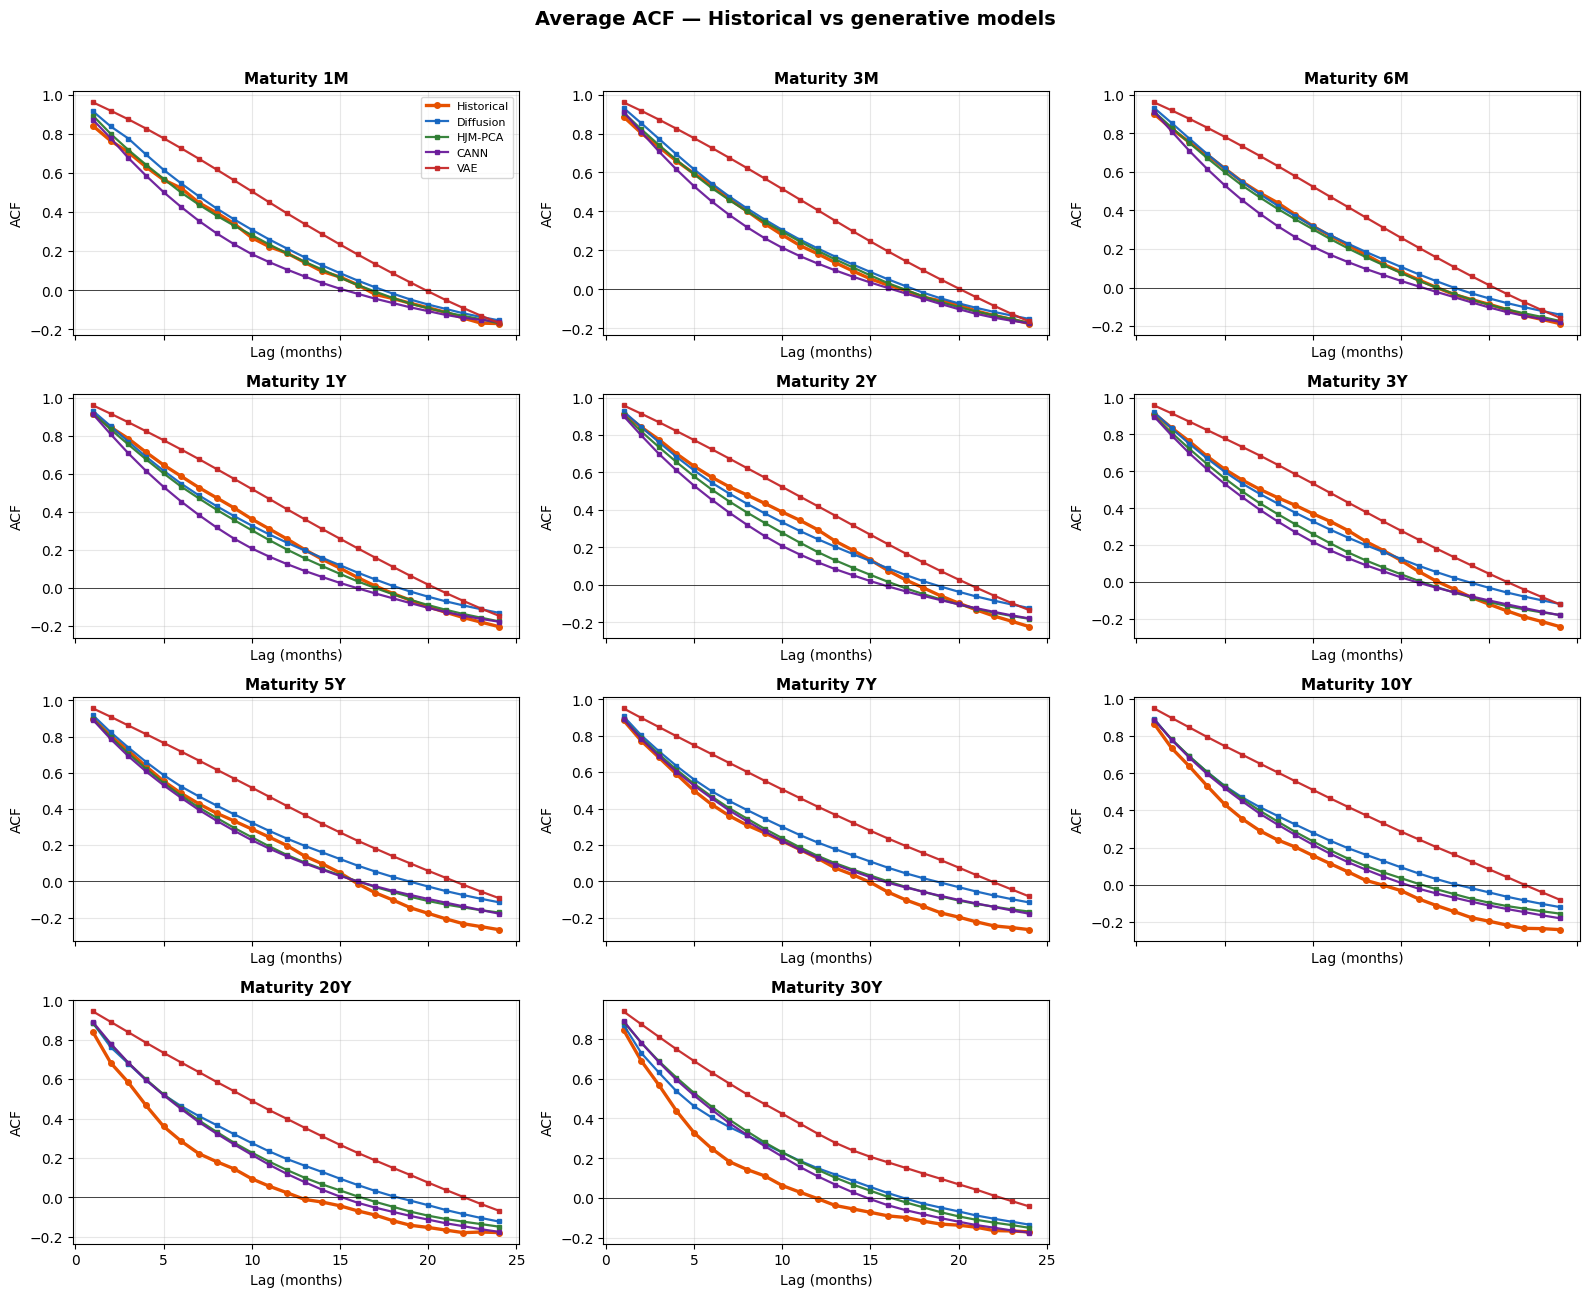

In [26]:
# ─────────────────────────────────────────────
# ACF — Historical vs every generative model
# ─────────────────────────────────────────────
# For every 60-month rolling window (historical) and every scenario (simulated)
# we compute the autocorrelation function per maturity up to K = 24 lags
# (a 2-year horizon, as in the evaluation). The mean historical ACF is the
# average across all hist_windows; the mean simulated ACF is the average
# across the 200 scenarios of each model.
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf

N_LAGS = 24                 # K in the evaluation (2-year horizon)
LAGS   = np.arange(1, N_LAGS + 1)


def acf_batch(paths, nlags=N_LAGS):
    """
    paths : (N, T, M)          — N paths, T timesteps, M maturities
    Returns (N, M, nlags) — ACF at lags 1..nlags, excluding lag 0.
    """
    N, T, M = paths.shape
    out = np.zeros((N, M, nlags))
    for n in range(N):
        for m in range(M):
            s = paths[n, :, m]
            if np.std(s) < 1e-10:
                continue
            out[n, m] = acf(s, nlags=nlags, fft=True)[1:]
    return out


# Historical ACF — averaged across every 60-month rolling window
hist_acf       = acf_batch(hist_windows)          # (n_windows, 11, K)
hist_acf_mean  = hist_acf.mean(axis=0)            # (11, K)

# Simulated ACF — one per scenario, averaged, per model
sim_acf       = {name: acf_batch(scenario_tensor(path))
                 for name, path in MODELS.items()}
sim_acf_mean  = {name: a.mean(axis=0) for name, a in sim_acf.items()}


# ─────────────────────────────────────────────
# Plot: 4×3 grid, one panel per maturity, all models on top of historical
# ─────────────────────────────────────────────
MODEL_COLORS = {
    "Diffusion": "#1565C0",
    "HJM-PCA":   "#2E7D32",
    "CANN":      "#6A1B9A",
    "VAE":       "#C62828",
}
HIST_COLOR = "#E65100"

n_mat = len(MATURITY_LABELS)
ncols = 3
nrows = int(np.ceil(n_mat / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.2), sharex=True)
fig.suptitle("Average ACF — Historical vs generative models",
             fontsize=14, fontweight="bold", y=1.01)

for idx, label in enumerate(MATURITY_LABELS):
    ax = axes.flat[idx]
    ax.plot(LAGS, hist_acf_mean[idx], color=HIST_COLOR, lw=2.4,
            marker="o", markersize=4, label="Historical")
    for name, mat_acf in sim_acf_mean.items():
        ax.plot(LAGS, mat_acf[idx], color=MODEL_COLORS[name], lw=1.6,
                alpha=0.95, marker="s", markersize=3, label=name)
    ax.axhline(0, color="black", lw=0.5)
    ax.set_title(f"Maturity {label}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Lag (months)")
    ax.set_ylabel("ACF")
    ax.grid(alpha=0.3)
    if idx == 0:
        ax.legend(fontsize=8, loc="upper right")

for ax in axes.flat[n_mat:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


### Per-maturity deviation score
For each maturity and model we compute the mean squared deviation between the simulated and historical average ACF (K = 24 lags), then average across the 200 scenarios. The bottom *Average* row collapses this further to a single number per model.

In [27]:
# ─────────────────────────────────────────────
# Per-maturity deviation score  S̄_m
# ─────────────────────────────────────────────
# For each scenario i and maturity m:
#         S_{i,m} = (1/K) Σ_k (ρ̂_{i,k,m} - ρ̄_k,m^{hist})²
# then averaged across the 200 scenarios of each model:
#         S̄_m     = (1/n) Σ_i S_{i,m}
# Lower values = the model reproduces the persistence structure at that
# maturity more faithfully.

per_mat_rows = {}
for name, a in sim_acf.items():
    # squared deviation per scenario, per maturity, averaged over lags → S_{i,m}
    S_im        = ((a - hist_acf_mean[None, :, :]) ** 2).mean(axis=2)   # (n_scen, 11)
    per_mat_rows[name] = S_im.mean(axis=0)                              # (11,)

acf_per_mat_df = pd.DataFrame(per_mat_rows, index=MATURITY_LABELS)
acf_per_mat_df.index.name = "Maturity"

# append column-average row
acf_per_mat_df.loc["Average"] = acf_per_mat_df.mean()

print("Per-maturity ACF deviation score  S̄_m  — lower is better")
print("=" * 70)
print(acf_per_mat_df.round(5).to_string())


Per-maturity ACF deviation score  S̄_m  — lower is better
          Diffusion  HJM-PCA  CANN   VAE
Maturity                                
1M            0.028    0.032 0.040 0.029
3M            0.027    0.031 0.037 0.028
6M            0.026    0.031 0.038 0.024
1Y            0.026    0.031 0.042 0.017
2Y            0.025    0.034 0.046 0.016
3Y            0.027    0.035 0.042 0.024
5Y            0.032    0.034 0.037 0.045
7Y            0.038    0.036 0.038 0.066
10Y           0.042    0.040 0.040 0.088
20Y           0.044    0.043 0.044 0.094
30Y           0.042    0.049 0.048 0.080
Average       0.033    0.036 0.041 0.047


### Global deviation score
The global score averages the per-maturity score over all 11 maturities within each scenario, then aggregates over the 200 scenarios. A single number summarises how well each model reproduces the persistence structure across the yield curve.

In [28]:
# ─────────────────────────────────────────────
# Global deviation score  S̄^{global}
# ─────────────────────────────────────────────
# Per-scenario global score averages S_{i,m} over all maturities:
#         S_i^{global} = (1/M) Σ_m S_{i,m}
# and the mean global score averages over scenarios:
#         S̄^{global}   = (1/n) Σ_i S_i^{global}

global_rows = []
for name, a in sim_acf.items():
    S_im         = ((a - hist_acf_mean[None, :, :]) ** 2).mean(axis=2)  # (n_scen, 11)
    S_global_i   = S_im.mean(axis=1)                                    # (n_scen,)
    global_rows.append({
        "Model":             name,
        "Mean S^global":     S_global_i.mean(),
        "Median S^global":   np.median(S_global_i),
        "Std S^global":      S_global_i.std(),
        "Min S^global":      S_global_i.min(),
        "Max S^global":      S_global_i.max(),
    })

acf_global_df = pd.DataFrame(global_rows).set_index("Model")

print("Global ACF deviation score  S̄^global  — lower is better")
print("=" * 70)
print(acf_global_df.round(5).to_string())


Global ACF deviation score  S̄^global  — lower is better
           Mean S^global  Median S^global  Std S^global  Min S^global  Max S^global
Model                                                                              
Diffusion          0.033            0.030         0.018         0.007         0.093
HJM-PCA            0.036            0.033         0.021         0.007         0.120
CANN               0.041            0.037         0.021         0.006         0.116
VAE                0.047            0.046         0.003         0.039         0.056


## shape

Historical: 232 monthly observations
Historical betas shape: (232, 3)
Simulated betas shape: (12000, 3)
Plot saved.

=== Beta Summary ===

beta1 (Level)
  Historical: mean=3.8872  std=1.2133  min=1.1389  max=6.2272
  Simulated:  mean=3.8436  std=1.2554  min=-1.2288  max=7.9849

beta2 (Slope)
  Historical: mean=-2.5705  std=1.5472  min=-5.1687  max=0.7164
  Simulated:  mean=-0.9839  std=1.9244  min=-9.6552  max=6.5394

beta3 (Curvature)
  Historical: mean=-3.1544  std=2.1160  min=-7.3461  max=0.7381
  Simulated:  mean=-5.8663  std=3.5841  min=-21.6214  max=3.0589


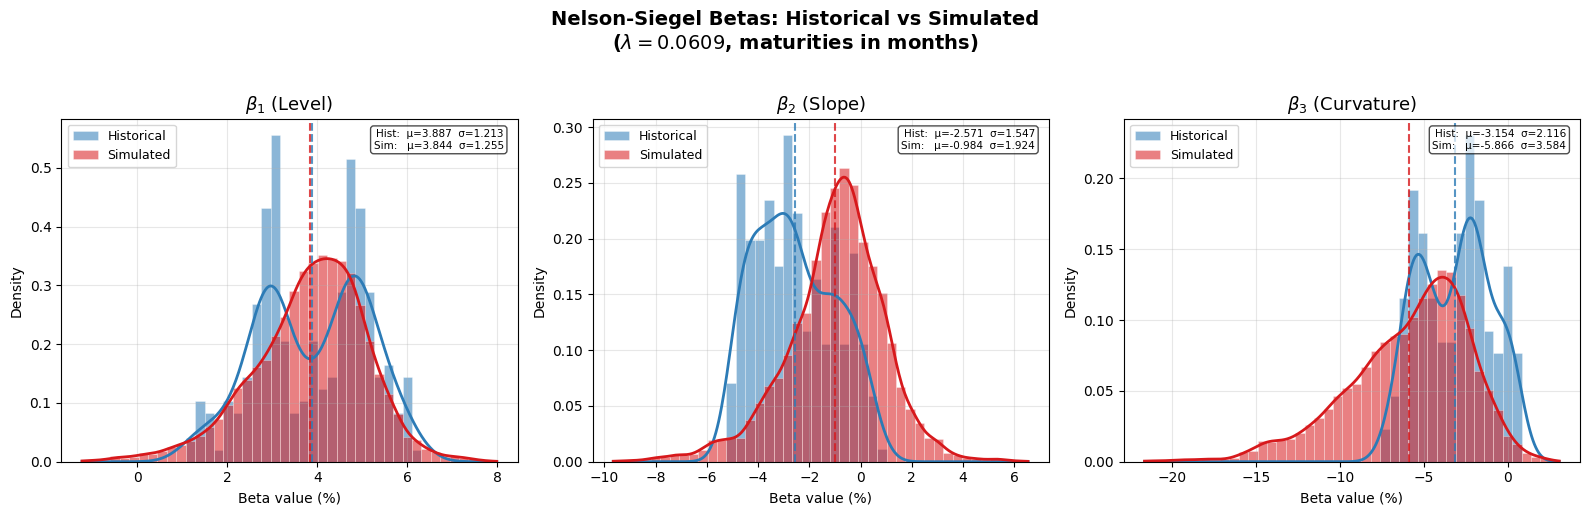

In [29]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# ── Nelson-Siegel setup ─────────────────────────────────────────────────────
LAMBDA = 0.0609  # global lambda (monthly units)

# Maturities in years → convert to months
HIST_MATS_YR   = np.array([1/12, 3/12, 6/12, 1, 2, 3, 5, 7, 10, 20, 30])
HIST_MATS_MO   = HIST_MATS_YR * 12

SIM_MATS_YR    = np.array([1/12, 3/12, 6/12, 1, 2, 3, 5, 7, 10, 20, 30])
SIM_MATS_MO    = SIM_MATS_YR * 12

def ns_loadings(tau, lam):
    """Returns (N,3) matrix of NS factor loadings for maturities tau (months)."""
    lt = lam * tau
    L1 = np.ones_like(lt)
    L2 = (1 - np.exp(-lt)) / lt
    L3 = L2 - np.exp(-lt)
    return np.column_stack([L1, L2, L3])

def fit_ns_ols(yields, tau, lam):
    """Fit Nelson-Siegel betas by OLS (closed-form)."""
    X = ns_loadings(tau, lam)
    # OLS: beta = (X'X)^-1 X'y
    betas, _, _, _ = np.linalg.lstsq(X, yields, rcond=None)
    return betas  # [beta0, beta1, beta2]

# ── 1. Historical data → monthly ────────────────────────────────────────────
hist_cols = ['Yield_1M', 'Yield_3M', 'Yield_6M', 'Yield_1Y', 'Yield_2Y',
             'Yield_3Y', 'Yield_5Y', 'Yield_7Y', 'Yield_10Y', 'Yield_20Y', 'Yield_30Y']

hist = pd.read_csv(historical_data, parse_dates=['DATE'])
hist = hist.set_index('DATE')[hist_cols]

# Resample to month-end (last observation of each month)
hist_monthly = hist.resample('ME').last()
print(f"Historical: {len(hist_monthly)} monthly observations")

# Fit NS for each month
hist_betas = []
for idx, row in hist_monthly.iterrows():
    b = fit_ns_ols(row.values, HIST_MATS_MO, LAMBDA)
    hist_betas.append(b)
hist_betas = np.array(hist_betas)   # shape (T, 3)
print(f"Historical betas shape: {hist_betas.shape}")

# ── 2. Simulated data ────────────────────────────────────────────────────────
sim_yield_cols = ['Y_1M', 'Y_3M', 'Y_6M', 'Y_1Y', 'Y_2Y', 'Y_3Y', 'Y_5Y', 'Y_7Y',
                  'Y_10Y', 'Y_20Y', 'Y_30Y']

sim = pd.read_csv(current_diffusion)

sim_betas = []
for _, row in sim.iterrows():
    b = fit_ns_ols(row[sim_yield_cols].values, SIM_MATS_MO, LAMBDA)
    sim_betas.append(b)
sim_betas = np.array(sim_betas)   # shape (12000, 3)
print(f"Simulated betas shape: {sim_betas.shape}")

# ── 3. Plotting ──────────────────────────────────────────────────────────────
beta_labels = [
    r'$\beta_1$ (Level)',
    r'$\beta_2$ (Slope)',
    r'$\beta_3$ (Curvature)'
]
colors_hist = '#2c7bb6'
colors_sim  = '#d7191c'

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Nelson-Siegel Betas: Historical vs Simulated\n'
             r'($\lambda = 0.0609$, maturities in months)',
             fontsize=14, fontweight='bold', y=1.02)

for i, (ax, label) in enumerate(zip(axes, beta_labels)):
    h_vals = hist_betas[:, i]
    s_vals = sim_betas[:, i]

    # Determine common bin range
    lo = min(h_vals.min(), s_vals.min())
    hi = max(h_vals.max(), s_vals.max())
    bins = np.linspace(lo, hi, 45)

    ax.hist(h_vals, bins=bins, density=True, alpha=0.55,
            color=colors_hist, label='Historical', edgecolor='white', linewidth=0.4)
    ax.hist(s_vals, bins=bins, density=True, alpha=0.55,
            color=colors_sim,  label='Simulated',  edgecolor='white', linewidth=0.4)

    # Add KDE lines
    from scipy.stats import gaussian_kde
    x_grid = np.linspace(lo, hi, 300)
    for vals, color in [(h_vals, colors_hist), (s_vals, colors_sim)]:
        kde = gaussian_kde(vals, bw_method='scott')
        ax.plot(x_grid, kde(x_grid), color=color, linewidth=2)

    # Summary stats
    ax.axvline(h_vals.mean(), color=colors_hist, linestyle='--', linewidth=1.5, alpha=0.8)
    ax.axvline(s_vals.mean(), color=colors_sim,  linestyle='--', linewidth=1.5, alpha=0.8)

    ax.set_title(label, fontsize=13)
    ax.set_xlabel('Beta value (%)', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Text box with stats
    stats_txt = (f"Hist:  μ={h_vals.mean():.3f}  σ={h_vals.std():.3f}\n"
                 f"Sim:   μ={s_vals.mean():.3f}  σ={s_vals.std():.3f}")
    ax.text(0.97, 0.97, stats_txt, transform=ax.transAxes,
            fontsize=7.5, va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.tight_layout()
#plt.savefig('ns_beta_distributions.png', dpi=160, bbox_inches='tight')
print("Plot saved.")

# ── 4. Print summary table ───────────────────────────────────────────────────
print("\n=== Beta Summary ===")
for i, name in enumerate(['beta1 (Level)', 'beta2 (Slope)', 'beta3 (Curvature)']):
    h, s = hist_betas[:, i], sim_betas[:, i]
    print(f"\n{name}")
    print(f"  Historical: mean={h.mean():.4f}  std={h.std():.4f}  "
          f"min={h.min():.4f}  max={h.max():.4f}")
    print(f"  Simulated:  mean={s.mean():.4f}  std={s.std():.4f}  "
          f"min={s.min():.4f}  max={s.max():.4f}")

In [30]:
from scipy.stats import wasserstein_distance
import pandas as pd
import numpy as np

# =========================
# FUNCTION
# =========================
def compute_wasserstein(hist_betas, sim_betas):
    results = []

    names = ["Level (β1)", "Slope (β2)", "Curvature (β3)"]

    for i, name in enumerate(names):
        h = hist_betas[:, i]
        s = sim_betas[:, i]

        w = wasserstein_distance(h, s)

        results.append({
            "Beta": name,
            "Wasserstein Distance": w,
            "Hist Mean": np.mean(h),
            "Sim Mean": np.mean(s),
            "Hist Std": np.std(h),
            "Sim Std": np.std(s)
        })

    return pd.DataFrame(results)

# =========================
# RUN
# =========================
comparison = compute_wasserstein(hist_betas, sim_betas)

print("\n=== Wasserstein Comparison ===")
print(comparison)


=== Wasserstein Comparison ===
             Beta  Wasserstein Distance  Hist Mean  Sim Mean  Hist Std  \
0      Level (β1)                 0.222      3.887     3.844     1.213   
1      Slope (β2)                 1.674     -2.571    -0.984     1.547   
2  Curvature (β3)                 2.724     -3.154    -5.866     2.116   

   Sim Std  
0    1.255  
1    1.924  
2    3.584  


### hjm-pca SHAPE

Historical: 232 monthly observations
Historical betas shape: (232, 3)
Simulated betas shape: (30000, 3)
Plot saved.

=== Beta Summary ===

beta1 (Level)
  Historical: mean=3.8872  std=1.2133  min=1.1389  max=6.2272
  Simulated:  mean=5.1400  std=1.4138  min=0.0828  max=11.0591

beta2 (Slope)
  Historical: mean=-2.5705  std=1.5472  min=-5.1687  max=0.7164
  Simulated:  mean=-1.3446  std=1.3399  min=-6.1777  max=4.2785

beta3 (Curvature)
  Historical: mean=-3.1544  std=2.1160  min=-7.3461  max=0.7381
  Simulated:  mean=-2.2140  std=2.5745  min=-12.2287  max=7.9409


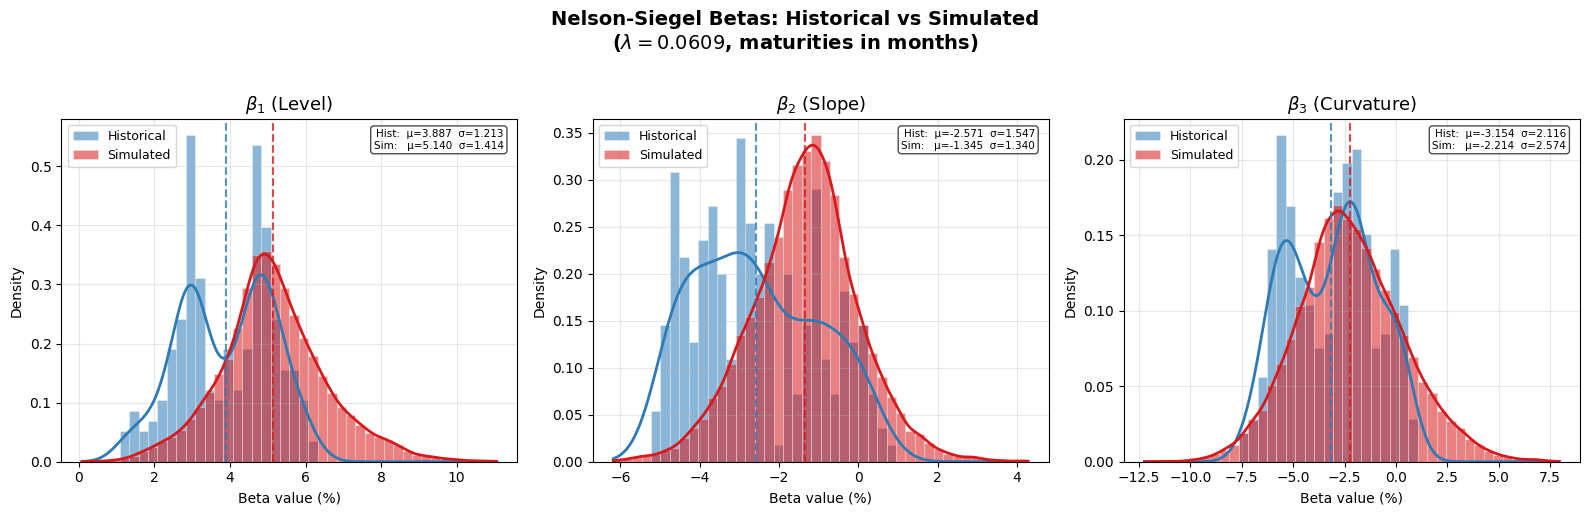

In [31]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# ── Nelson-Siegel setup ─────────────────────────────────────────────────────
LAMBDA = 0.0609  # global lambda (monthly units)

# Maturities in years → convert to months
HIST_MATS_YR   = np.array([1/12, 3/12, 6/12, 1, 2, 3, 5, 7, 10, 20, 30])
HIST_MATS_MO   = HIST_MATS_YR * 12

SIM_MATS_YR    = np.array([1/12, 3/12, 6/12, 1, 2, 3, 5, 7, 10, 20, 30])
SIM_MATS_MO    = SIM_MATS_YR * 12

def ns_loadings(tau, lam):
    """Returns (N,3) matrix of NS factor loadings for maturities tau (months)."""
    lt = lam * tau
    L1 = np.ones_like(lt)
    L2 = (1 - np.exp(-lt)) / lt
    L3 = L2 - np.exp(-lt)
    return np.column_stack([L1, L2, L3])

def fit_ns_ols(yields, tau, lam):
    """Fit Nelson-Siegel betas by OLS (closed-form)."""
    X = ns_loadings(tau, lam)
    # OLS: beta = (X'X)^-1 X'y
    betas, _, _, _ = np.linalg.lstsq(X, yields, rcond=None)
    return betas  # [beta0, beta1, beta2]

# ── 1. Historical data → monthly ────────────────────────────────────────────
hist_cols = ['Yield_1M', 'Yield_3M', 'Yield_6M', 'Yield_1Y', 'Yield_2Y',
             'Yield_3Y', 'Yield_5Y', 'Yield_7Y', 'Yield_10Y', 'Yield_20Y', 'Yield_30Y']

hist = pd.read_csv(historical_data, parse_dates=['DATE'])
hist = hist.set_index('DATE')[hist_cols]

# Resample to month-end (last observation of each month)
hist_monthly = hist.resample('ME').last()
print(f"Historical: {len(hist_monthly)} monthly observations")

# Fit NS for each month
hist_betas = []
for idx, row in hist_monthly.iterrows():
    b = fit_ns_ols(row.values, HIST_MATS_MO, LAMBDA)
    hist_betas.append(b)
hist_betas = np.array(hist_betas)   # shape (T, 3)
print(f"Historical betas shape: {hist_betas.shape}")

# ── 2. Simulated data ────────────────────────────────────────────────────────
sim_yield_cols = ['Y_1M', 'Y_3M', 'Y_6M', 'Y_1Y', 'Y_2Y', 'Y_3Y', 'Y_5Y', 'Y_7Y',
                  'Y_10Y', 'Y_20Y', 'Y_30Y']

sim = pd.read_csv(hjm_data)

sim_betas = []
for _, row in sim.iterrows():
    b = fit_ns_ols(row[sim_yield_cols].values, SIM_MATS_MO, LAMBDA)
    sim_betas.append(b)
sim_betas = np.array(sim_betas)   # shape (12000, 3)
print(f"Simulated betas shape: {sim_betas.shape}")

# ── 3. Plotting ──────────────────────────────────────────────────────────────
beta_labels = [
    r'$\beta_1$ (Level)',
    r'$\beta_2$ (Slope)',
    r'$\beta_3$ (Curvature)'
]
colors_hist = '#2c7bb6'
colors_sim  = '#d7191c'

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Nelson-Siegel Betas: Historical vs Simulated\n'
             r'($\lambda = 0.0609$, maturities in months)',
             fontsize=14, fontweight='bold', y=1.02)

for i, (ax, label) in enumerate(zip(axes, beta_labels)):
    h_vals = hist_betas[:, i]
    s_vals = sim_betas[:, i]

    # Determine common bin range
    lo = min(h_vals.min(), s_vals.min())
    hi = max(h_vals.max(), s_vals.max())
    bins = np.linspace(lo, hi, 45)

    ax.hist(h_vals, bins=bins, density=True, alpha=0.55,
            color=colors_hist, label='Historical', edgecolor='white', linewidth=0.4)
    ax.hist(s_vals, bins=bins, density=True, alpha=0.55,
            color=colors_sim,  label='Simulated',  edgecolor='white', linewidth=0.4)

    # Add KDE lines
    from scipy.stats import gaussian_kde
    x_grid = np.linspace(lo, hi, 300)
    for vals, color in [(h_vals, colors_hist), (s_vals, colors_sim)]:
        kde = gaussian_kde(vals, bw_method='scott')
        ax.plot(x_grid, kde(x_grid), color=color, linewidth=2)

    # Summary stats
    ax.axvline(h_vals.mean(), color=colors_hist, linestyle='--', linewidth=1.5, alpha=0.8)
    ax.axvline(s_vals.mean(), color=colors_sim,  linestyle='--', linewidth=1.5, alpha=0.8)

    ax.set_title(label, fontsize=13)
    ax.set_xlabel('Beta value (%)', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Text box with stats
    stats_txt = (f"Hist:  μ={h_vals.mean():.3f}  σ={h_vals.std():.3f}\n"
                 f"Sim:   μ={s_vals.mean():.3f}  σ={s_vals.std():.3f}")
    ax.text(0.97, 0.97, stats_txt, transform=ax.transAxes,
            fontsize=7.5, va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.tight_layout()
#plt.savefig('ns_beta_distributions.png', dpi=160, bbox_inches='tight')
print("Plot saved.")

# ── 4. Print summary table ───────────────────────────────────────────────────
print("\n=== Beta Summary ===")
for i, name in enumerate(['beta1 (Level)', 'beta2 (Slope)', 'beta3 (Curvature)']):
    h, s = hist_betas[:, i], sim_betas[:, i]
    print(f"\n{name}")
    print(f"  Historical: mean={h.mean():.4f}  std={h.std():.4f}  "
          f"min={h.min():.4f}  max={h.max():.4f}")
    print(f"  Simulated:  mean={s.mean():.4f}  std={s.std():.4f}  "
          f"min={s.min():.4f}  max={s.max():.4f}")

In [32]:
from scipy.stats import wasserstein_distance
import pandas as pd
import numpy as np

# =========================
# FUNCTION
# =========================
def compute_wasserstein(hist_betas, sim_betas):
    results = []

    names = ["Level (β1)", "Slope (β2)", "Curvature (β3)"]

    for i, name in enumerate(names):
        h = hist_betas[:, i]
        s = sim_betas[:, i]

        w = wasserstein_distance(h, s)

        results.append({
            "Beta": name,
            "Wasserstein Distance": w,
            "Hist Mean": np.mean(h),
            "Sim Mean": np.mean(s),
            "Hist Std": np.std(h),
            "Sim Std": np.std(s)
        })

    return pd.DataFrame(results)

# =========================
# RUN
# =========================
comparison = compute_wasserstein(hist_betas, sim_betas)

print("\n=== Wasserstein Comparison ===")
print(comparison)


=== Wasserstein Comparison ===
             Beta  Wasserstein Distance  Hist Mean  Sim Mean  Hist Std  \
0      Level (β1)                 1.254      3.887     5.140     1.213   
1      Slope (β2)                 1.229     -2.571    -1.345     1.547   
2  Curvature (β3)                 0.993     -3.154    -2.214     2.116   

   Sim Std  
0    1.414  
1    1.340  
2    2.574  


## cross-maturity correlatie


### diffusion maturity correlation

Loading historical data …
  Monthly observations: 232  (2002-01 → 2021-04)

Computing historical cross-correlation matrices (window = 60 months, stride = 1) …
  Number of 5-year windows: 173
  Mean cross-correlation matrix shape: (11, 11)

Loading simulated paths …
  Scenarios: 200  |  Months per scenario: [60]
Computing simulated cross-correlation matrices …
  Mean cross-correlation matrix shape: (11, 11)

──────────────────────────────────────────────────
  L1 norm  Σ_i Σ_j |τ_real^ij - τ_sim^ij|  =  16.102601
  (d=11 maturities  →  121 matrix entries)
──────────────────────────────────────────────────


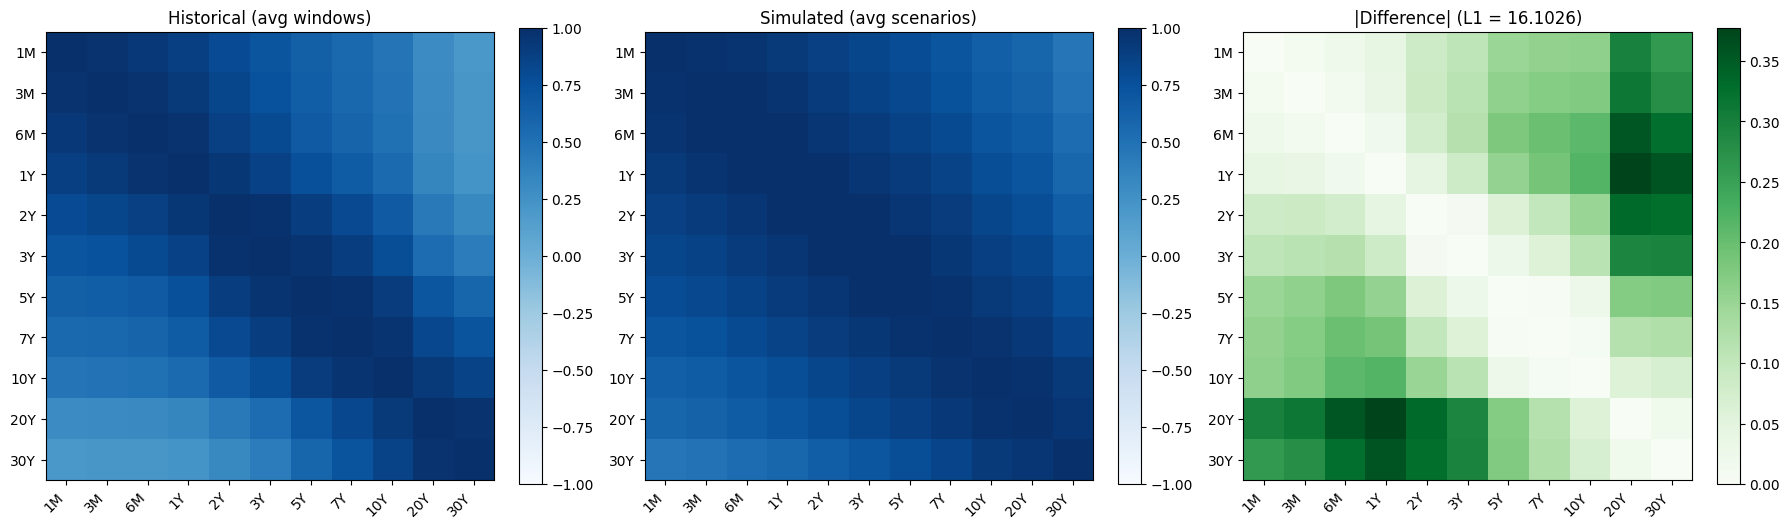


── Historical mean cross-correlation matrix ──
       1M    3M    6M    1Y    2Y    3Y    5Y    7Y   10Y   20Y   30Y
1M  1.000 0.970 0.934 0.882 0.786 0.717 0.625 0.555 0.475 0.291 0.203
3M  0.970 1.000 0.972 0.919 0.821 0.746 0.646 0.571 0.488 0.300 0.209
6M  0.934 0.972 1.000 0.969 0.873 0.790 0.679 0.596 0.503 0.306 0.207
1Y  0.882 0.919 0.969 1.000 0.942 0.867 0.751 0.659 0.549 0.336 0.228
2Y  0.786 0.821 0.873 0.942 1.000 0.977 0.890 0.800 0.672 0.436 0.318
3Y  0.717 0.746 0.790 0.867 0.977 1.000 0.959 0.887 0.767 0.533 0.411
5Y  0.625 0.646 0.679 0.751 0.890 0.959 1.000 0.979 0.904 0.707 0.592
7Y  0.555 0.571 0.596 0.659 0.800 0.887 0.979 1.000 0.968 0.819 0.720
10Y 0.475 0.488 0.503 0.549 0.672 0.767 0.904 0.968 1.000 0.923 0.845
20Y 0.291 0.300 0.306 0.336 0.436 0.533 0.707 0.819 0.923 1.000 0.972
30Y 0.203 0.209 0.207 0.228 0.318 0.411 0.592 0.720 0.845 0.972 1.000

── Simulated mean cross-correlation matrix ──
       1M    3M    6M    1Y    2Y    3Y    5Y    7Y   10Y   20Y  

In [33]:
"""
Cross-Maturity Correlation Analysis
Based on Liao et al. (2024) "Sig-Wasserstein GANs for conditional time series generation"
Cross-correlation metric: Appendix C, Equations (C.3) and (C.4)

L1 norm of real vs generated cross-correlation matrices:
    metric = sum_i sum_j |tau^{i,j}_r - tau^{i,j}_G|

where tau^{i,j} = cov^{i,j} / sqrt(cov^{i,i} * cov^{j,j})
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from matplotlib.gridspec import GridSpec

# ─────────────────────────────────────────────
# 0. Configuration
# ─────────────────────────────────────────────
YIELD_COLS_HIST = [
    "Yield_1M", "Yield_3M", "Yield_6M", "Yield_1Y",
    "Yield_2Y", "Yield_3Y", "Yield_5Y", "Yield_7Y",
    "Yield_10Y", "Yield_20Y", "Yield_30Y"
]
YIELD_COLS_SIM = [
    "Y_1M", "Y_3M", "Y_6M", "Y_1Y",
    "Y_2Y", "Y_3Y", "Y_5Y", "Y_7Y",
    "Y_10Y", "Y_20Y", "Y_30Y"
]
MATURITY_LABELS = [
    "1M", "3M", "6M", "1Y",
    "2Y", "3Y", "5Y", "7Y",
    "10Y", "20Y", "30Y"
]
WINDOW_MONTHS = 60   # 5-year sliding window to match 60-month simulated paths

# ─────────────────────────────────────────────
# 1. Helper: cross-correlation matrix per Eq (C.3)
# ─────────────────────────────────────────────
def cross_corr_matrix(X: np.ndarray) -> np.ndarray:
    """
    X : (T, d) array of time series observations
    Returns (d, d) correlation matrix tau where
        tau^{i,j} = cov^{i,j} / sqrt(cov^{i,i} * cov^{j,j})
    using the unbiased sample estimator from paper Eq (C.3):
        cov^{i,j} = (1/T) sum_t X^i_t X^j_t - (1/T sum X^i)(1/T sum X^j)
    """
    T = X.shape[0]
    mean = X.mean(axis=0)                    # (d,)
    cov = (X.T @ X) / T - np.outer(mean, mean)   # (d, d)  -- Eq (C.3)
    std = np.sqrt(np.diag(cov))              # (d,)
    outer_std = np.outer(std, std)
    # avoid div/0
    corr = np.where(outer_std > 0, cov / outer_std, 0.0)
    return corr

# ─────────────────────────────────────────────
# 2. Load & pre-process historical data
# ─────────────────────────────────────────────
print("Loading historical data …")
hist = pd.read_csv(historical_data)

# Remove GDP, Fed Funds and CPI columns; keep only yield curve
# GDP → Real_GDP | Fed → FedFunds | (CPI_Level implicitly removed)
hist = hist[["DATE"] + YIELD_COLS_HIST].copy()
hist["DATE"] = pd.to_datetime(hist["DATE"])
hist = hist.sort_values("DATE").reset_index(drop=True)

# Aggregate daily → monthly (end-of-month last observation)
hist["YearMonth"] = hist["DATE"].dt.to_period("M")
hist_monthly = (hist.groupby("YearMonth")[YIELD_COLS_HIST]
                .last()
                .reset_index())
hist_monthly = hist_monthly.sort_values("YearMonth").reset_index(drop=True)

n_months = len(hist_monthly)
print(f"  Monthly observations: {n_months}  "
      f"({hist_monthly['YearMonth'].iloc[0]} → {hist_monthly['YearMonth'].iloc[-1]})")

# ─────────────────────────────────────────────
# 3. Sliding-window cross-correlation matrices (historical)
# ─────────────────────────────────────────────
print(f"\nComputing historical cross-correlation matrices "
      f"(window = {WINDOW_MONTHS} months, stride = 1) …")

hist_values = hist_monthly[YIELD_COLS_HIST].values  # (n_months, 11)
n_windows = n_months - WINDOW_MONTHS + 1

hist_corr_matrices = []
for start in range(n_windows):
    window = hist_values[start : start + WINDOW_MONTHS]   # (60, 11)
    hist_corr_matrices.append(cross_corr_matrix(window))

hist_corr_matrices = np.array(hist_corr_matrices)   # (n_windows, 11, 11)
hist_mean_corr = hist_corr_matrices.mean(axis=0)    # average across windows

print(f"  Number of 5-year windows: {n_windows}")
print(f"  Mean cross-correlation matrix shape: {hist_mean_corr.shape}")

# ─────────────────────────────────────────────
# 4. Load & process simulated data
# ─────────────────────────────────────────────
print("\nLoading simulated paths …")
sim = pd.read_csv(current_diffusion)
scenarios = sim["Scenario_ID"].unique()
n_scenarios = len(scenarios)
months_per_scenario = sim.groupby("Scenario_ID")["Month"].count().unique()
print(f"  Scenarios: {n_scenarios}  |  Months per scenario: {months_per_scenario}")

# Per paper Eq (C.4): compute cov matrix per scenario, then average
print("Computing simulated cross-correlation matrices …")
sim_corr_matrices = []
for sc_id in scenarios:
    sc_data = sim[sim["Scenario_ID"] == sc_id][YIELD_COLS_SIM].values  # (60, 11)
    sim_corr_matrices.append(cross_corr_matrix(sc_data))

sim_corr_matrices = np.array(sim_corr_matrices)     # (n_scenarios, 11, 11)
sim_mean_corr = sim_corr_matrices.mean(axis=0)       # average across scenarios

print(f"  Mean cross-correlation matrix shape: {sim_mean_corr.shape}")

# ─────────────────────────────────────────────
# 5. L1 norm  (paper Section 6, Feature dependency metric)
# ─────────────────────────────────────────────
diff_matrix = np.abs(hist_mean_corr - sim_mean_corr)
l1_norm = diff_matrix.sum()

print(f"\n{'─'*50}")
print(f"  L1 norm  Σ_i Σ_j |τ_real^ij - τ_sim^ij|  =  {l1_norm:.6f}")
print(f"  (d={len(MATURITY_LABELS)} maturities  →  {len(MATURITY_LABELS)**2} matrix entries)")
print(f"{'─'*50}")

# ─────────────────────────────────────────────
# 6. Visualisation (clean white style)
# ─────────────────────────────────────────────
plt.style.use("default")  # reset to standard white theme

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Historical
im0 = axes[0].imshow(hist_mean_corr, cmap="Blues", vmin=-1, vmax=1)
axes[0].set_title("Historical (avg windows)")

# Simulated
im1 = axes[1].imshow(sim_mean_corr, cmap="Blues", vmin=-1, vmax=1)
axes[1].set_title("Simulated (avg scenarios)")

# Difference
im2 = axes[2].imshow(diff_matrix, cmap="Greens")
axes[2].set_title(f"|Difference| (L1 = {l1_norm:.4f})")

# Axis labels
for ax in axes:
    ax.set_xticks(range(len(MATURITY_LABELS)))
    ax.set_yticks(range(len(MATURITY_LABELS)))
    ax.set_xticklabels(MATURITY_LABELS, rotation=45, ha="right")
    ax.set_yticklabels(MATURITY_LABELS)

# Colorbars
fig.colorbar(im0, ax=axes[0], fraction=0.046)
fig.colorbar(im1, ax=axes[1], fraction=0.046)
fig.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# 8. Print summary table
# ─────────────────────────────────────────────
print("\n── Historical mean cross-correlation matrix ──")
df_hist = pd.DataFrame(hist_mean_corr, index=MATURITY_LABELS, columns=MATURITY_LABELS)
print(df_hist.round(4).to_string())

print("\n── Simulated mean cross-correlation matrix ──")
df_sim = pd.DataFrame(sim_mean_corr, index=MATURITY_LABELS, columns=MATURITY_LABELS)
print(df_sim.round(4).to_string())

print("\n── |Difference| matrix ──")
df_diff = pd.DataFrame(diff_matrix, index=MATURITY_LABELS, columns=MATURITY_LABELS)
print(df_diff.round(4).to_string())

print(f"\n{'═'*50}")
print(f"  FINAL  L¹ norm = {l1_norm:.6f}")
print(f"{'═'*50}")
print("\nDone.")


### HJM maturity correlation

Loading historical data …
  Monthly observations: 232  (2002-01 → 2021-04)

Computing historical cross-correlation matrices (window = 60 months, stride = 1) …
  Number of 5-year windows: 173
  Mean cross-correlation matrix shape: (11, 11)

Loading simulated paths …
  Scenarios: 500  |  Months per scenario: [60]
Computing simulated cross-correlation matrices …
  Mean cross-correlation matrix shape: (11, 11)

──────────────────────────────────────────────────
  L1 norm  Σ_i Σ_j |τ_real^ij - τ_sim^ij|  =  9.147322
  (d=11 maturities  →  121 matrix entries)
──────────────────────────────────────────────────


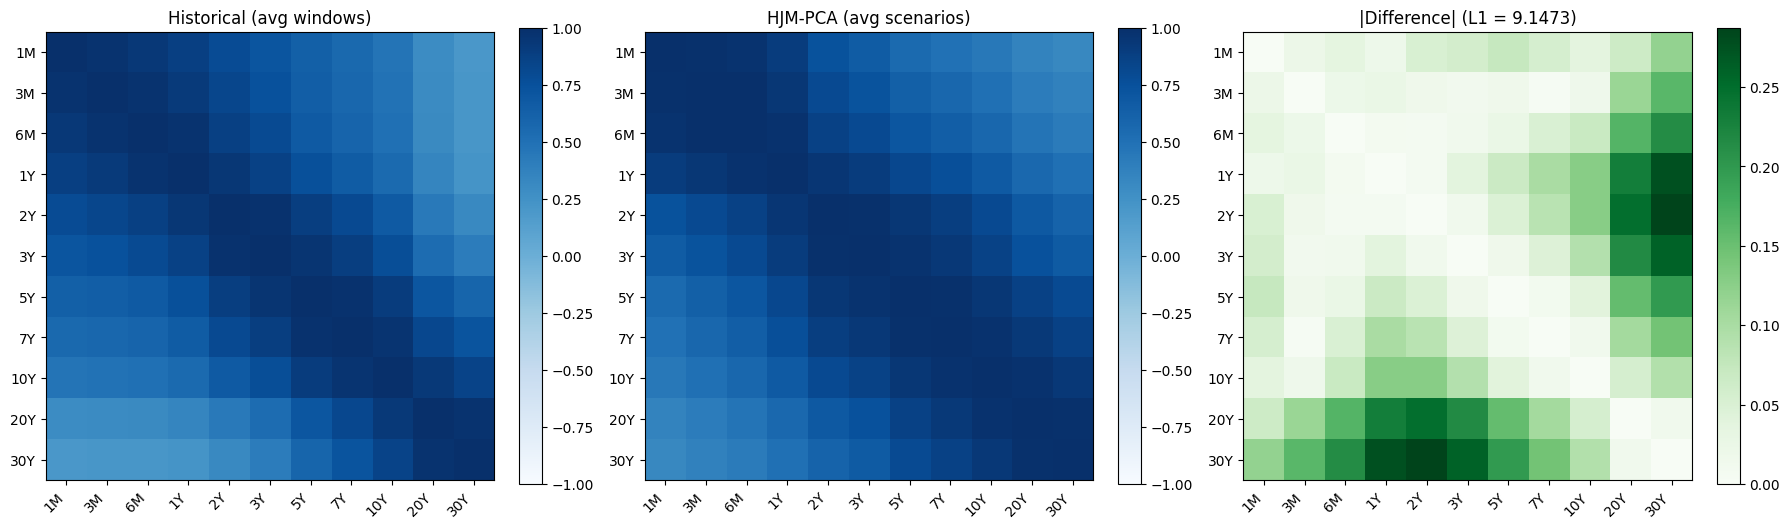


── Historical mean cross-correlation matrix ──
       1M    3M    6M    1Y    2Y    3Y    5Y    7Y   10Y   20Y   30Y
1M  1.000 0.970 0.934 0.882 0.786 0.717 0.625 0.555 0.475 0.291 0.203
3M  0.970 1.000 0.972 0.919 0.821 0.746 0.646 0.571 0.488 0.300 0.209
6M  0.934 0.972 1.000 0.969 0.873 0.790 0.679 0.596 0.503 0.306 0.207
1Y  0.882 0.919 0.969 1.000 0.942 0.867 0.751 0.659 0.549 0.336 0.228
2Y  0.786 0.821 0.873 0.942 1.000 0.977 0.890 0.800 0.672 0.436 0.318
3Y  0.717 0.746 0.790 0.867 0.977 1.000 0.959 0.887 0.767 0.533 0.411
5Y  0.625 0.646 0.679 0.751 0.890 0.959 1.000 0.979 0.904 0.707 0.592
7Y  0.555 0.571 0.596 0.659 0.800 0.887 0.979 1.000 0.968 0.819 0.720
10Y 0.475 0.488 0.503 0.549 0.672 0.767 0.904 0.968 1.000 0.923 0.845
20Y 0.291 0.300 0.306 0.336 0.436 0.533 0.707 0.819 0.923 1.000 0.972
30Y 0.203 0.209 0.207 0.228 0.318 0.411 0.592 0.720 0.845 0.972 1.000

── Simulated mean cross-correlation matrix ──
       1M    3M    6M    1Y    2Y    3Y    5Y    7Y   10Y   20Y  

In [34]:
"""
Cross-Maturity Correlation Analysis
Based on Liao et al. (2024) "Sig-Wasserstein GANs for conditional time series generation"
Cross-correlation metric: Appendix C, Equations (C.3) and (C.4)

L1 norm of real vs generated cross-correlation matrices:
    metric = sum_i sum_j |tau^{i,j}_r - tau^{i,j}_G|

where tau^{i,j} = cov^{i,j} / sqrt(cov^{i,i} * cov^{j,j})
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from matplotlib.gridspec import GridSpec

# ─────────────────────────────────────────────
# 0. Configuration
# ─────────────────────────────────────────────
YIELD_COLS_HIST = [
    "Yield_1M", "Yield_3M", "Yield_6M", "Yield_1Y",
    "Yield_2Y", "Yield_3Y", "Yield_5Y", "Yield_7Y",
    "Yield_10Y", "Yield_20Y", "Yield_30Y"
]
YIELD_COLS_SIM = [
    "Y_1M", "Y_3M", "Y_6M", "Y_1Y",
    "Y_2Y", "Y_3Y", "Y_5Y", "Y_7Y",
    "Y_10Y", "Y_20Y", "Y_30Y"
]
MATURITY_LABELS = [
    "1M", "3M", "6M", "1Y",
    "2Y", "3Y", "5Y", "7Y",
    "10Y", "20Y", "30Y"
]
WINDOW_MONTHS = 60   # 5-year sliding window to match 60-month simulated paths

# ─────────────────────────────────────────────
# 1. Helper: cross-correlation matrix per Eq (C.3)
# ─────────────────────────────────────────────
def cross_corr_matrix(X: np.ndarray) -> np.ndarray:
    """
    X : (T, d) array of time series observations
    Returns (d, d) correlation matrix tau where
        tau^{i,j} = cov^{i,j} / sqrt(cov^{i,i} * cov^{j,j})
    using the unbiased sample estimator from paper Eq (C.3):
        cov^{i,j} = (1/T) sum_t X^i_t X^j_t - (1/T sum X^i)(1/T sum X^j)
    """
    T = X.shape[0]
    mean = X.mean(axis=0)                    # (d,)
    cov = (X.T @ X) / T - np.outer(mean, mean)   # (d, d)  -- Eq (C.3)
    std = np.sqrt(np.diag(cov))              # (d,)
    outer_std = np.outer(std, std)
    # avoid div/0
    corr = np.where(outer_std > 0, cov / outer_std, 0.0)
    return corr

# ─────────────────────────────────────────────
# 2. Load & pre-process historical data
# ─────────────────────────────────────────────
print("Loading historical data …")
hist = pd.read_csv(historical_data)

# Remove GDP, Fed Funds and CPI columns; keep only yield curve
# GDP → Real_GDP | Fed → FedFunds | (CPI_Level implicitly removed)
hist = hist[["DATE"] + YIELD_COLS_HIST].copy()
hist["DATE"] = pd.to_datetime(hist["DATE"])
hist = hist.sort_values("DATE").reset_index(drop=True)

# Aggregate daily → monthly (end-of-month last observation)
hist["YearMonth"] = hist["DATE"].dt.to_period("M")
hist_monthly = (hist.groupby("YearMonth")[YIELD_COLS_HIST]
                .last()
                .reset_index())
hist_monthly = hist_monthly.sort_values("YearMonth").reset_index(drop=True)

n_months = len(hist_monthly)
print(f"  Monthly observations: {n_months}  "
      f"({hist_monthly['YearMonth'].iloc[0]} → {hist_monthly['YearMonth'].iloc[-1]})")

# ─────────────────────────────────────────────
# 3. Sliding-window cross-correlation matrices (historical)
# ─────────────────────────────────────────────
print(f"\nComputing historical cross-correlation matrices "
      f"(window = {WINDOW_MONTHS} months, stride = 1) …")

hist_values = hist_monthly[YIELD_COLS_HIST].values  # (n_months, 11)
n_windows = n_months - WINDOW_MONTHS + 1

hist_corr_matrices = []
for start in range(n_windows):
    window = hist_values[start : start + WINDOW_MONTHS]   # (60, 11)
    hist_corr_matrices.append(cross_corr_matrix(window))

hist_corr_matrices = np.array(hist_corr_matrices)   # (n_windows, 11, 11)
hist_mean_corr = hist_corr_matrices.mean(axis=0)    # average across windows

print(f"  Number of 5-year windows: {n_windows}")
print(f"  Mean cross-correlation matrix shape: {hist_mean_corr.shape}")

# ─────────────────────────────────────────────
# 4. Load & process simulated data
# ─────────────────────────────────────────────
print("\nLoading simulated paths …")
sim = pd.read_csv(hjm_data)
scenarios = sim["Scenario_ID"].unique()
n_scenarios = len(scenarios)
months_per_scenario = sim.groupby("Scenario_ID")["Month"].count().unique()
print(f"  Scenarios: {n_scenarios}  |  Months per scenario: {months_per_scenario}")

# Per paper Eq (C.4): compute cov matrix per scenario, then average
print("Computing simulated cross-correlation matrices …")
sim_corr_matrices = []
for sc_id in scenarios:
    sc_data = sim[sim["Scenario_ID"] == sc_id][YIELD_COLS_SIM].values  # (60, 11)
    sim_corr_matrices.append(cross_corr_matrix(sc_data))

sim_corr_matrices = np.array(sim_corr_matrices)     # (n_scenarios, 11, 11)
sim_mean_corr = sim_corr_matrices.mean(axis=0)       # average across scenarios

print(f"  Mean cross-correlation matrix shape: {sim_mean_corr.shape}")

# ─────────────────────────────────────────────
# 5. L1 norm  (paper Section 6, Feature dependency metric)
# ─────────────────────────────────────────────
diff_matrix = np.abs(hist_mean_corr - sim_mean_corr)
l1_norm = diff_matrix.sum()

print(f"\n{'─'*50}")
print(f"  L1 norm  Σ_i Σ_j |τ_real^ij - τ_sim^ij|  =  {l1_norm:.6f}")
print(f"  (d={len(MATURITY_LABELS)} maturities  →  {len(MATURITY_LABELS)**2} matrix entries)")
print(f"{'─'*50}")

# ─────────────────────────────────────────────
# 6. Visualisation (clean white style)
# ─────────────────────────────────────────────
plt.style.use("default")  # reset to standard white theme

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Historical
im0 = axes[0].imshow(hist_mean_corr, cmap="Blues", vmin=-1, vmax=1)
axes[0].set_title("Historical (avg windows)")

# Simulated
im1 = axes[1].imshow(sim_mean_corr, cmap="Blues", vmin=-1, vmax=1)
axes[1].set_title("HJM-PCA (avg scenarios)")

# Difference
im2 = axes[2].imshow(diff_matrix, cmap="Greens")
axes[2].set_title(f"|Difference| (L1 = {l1_norm:.4f})")

# Axis labels
for ax in axes:
    ax.set_xticks(range(len(MATURITY_LABELS)))
    ax.set_yticks(range(len(MATURITY_LABELS)))
    ax.set_xticklabels(MATURITY_LABELS, rotation=45, ha="right")
    ax.set_yticklabels(MATURITY_LABELS)

# Colorbars
fig.colorbar(im0, ax=axes[0], fraction=0.046)
fig.colorbar(im1, ax=axes[1], fraction=0.046)
fig.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# 8. Print summary table
# ─────────────────────────────────────────────
print("\n── Historical mean cross-correlation matrix ──")
df_hist = pd.DataFrame(hist_mean_corr, index=MATURITY_LABELS, columns=MATURITY_LABELS)
print(df_hist.round(4).to_string())

print("\n── Simulated mean cross-correlation matrix ──")
df_sim = pd.DataFrame(sim_mean_corr, index=MATURITY_LABELS, columns=MATURITY_LABELS)
print(df_sim.round(4).to_string())

print("\n── |Difference| matrix ──")
df_diff = pd.DataFrame(diff_matrix, index=MATURITY_LABELS, columns=MATURITY_LABELS)
print(df_diff.round(4).to_string())

print(f"\n{'═'*50}")
print(f"  FINAL  L¹ norm = {l1_norm:.6f}")
print(f"{'═'*50}")
print("\nDone.")


## Tail scenarios & Novelty

### Tail scenarios


  TAIL BEHAVIOUR & EXTREME SCENARIO EVALUATION

[1] Loading data...
  Historical: 4836 daily → 232 monthly obs (2002-01-31 to 2021-04-30)
  Scenarios : 200 scenarios × 60 timesteps × 11 maturities
  Scenarios : 500 scenarios × 60 timesteps × 11 maturities

[2] Computing Nelson-Siegel loadings (λ=0.0609)...

[3] Extracting NS factors...
  Historical rolling windows:
  Historical NS: 173 windows → 10380 factor obs
  MVP1 scenarios:
  HJM-PCA scenarios:

[4] Computing shape-based tail thresholds from historical NS factors...
  β1 (Level): [2.4073, 5.2361]
  β2 (Slope): [-4.7168, 0.1926]
  β3 (Curvature): [-6.3200, 0.1706]

[5] Computing shape-based outlier frequencies...

[6] Computing dynamic tail thresholds from historical Δβ...
  Δβ1: [-0.4412, 0.4131]
  Δβ2: [-0.6647, 0.5529]
  Δβ3: [-1.0605, 0.9750]

[7] Computing dynamic outlier frequencies...

[8] Building summary tables...

  SHAPE-BASED TAIL FREQUENCY  (thresholds: P5/P95 of historical NS factors)
  % of (timestep × factor) obse

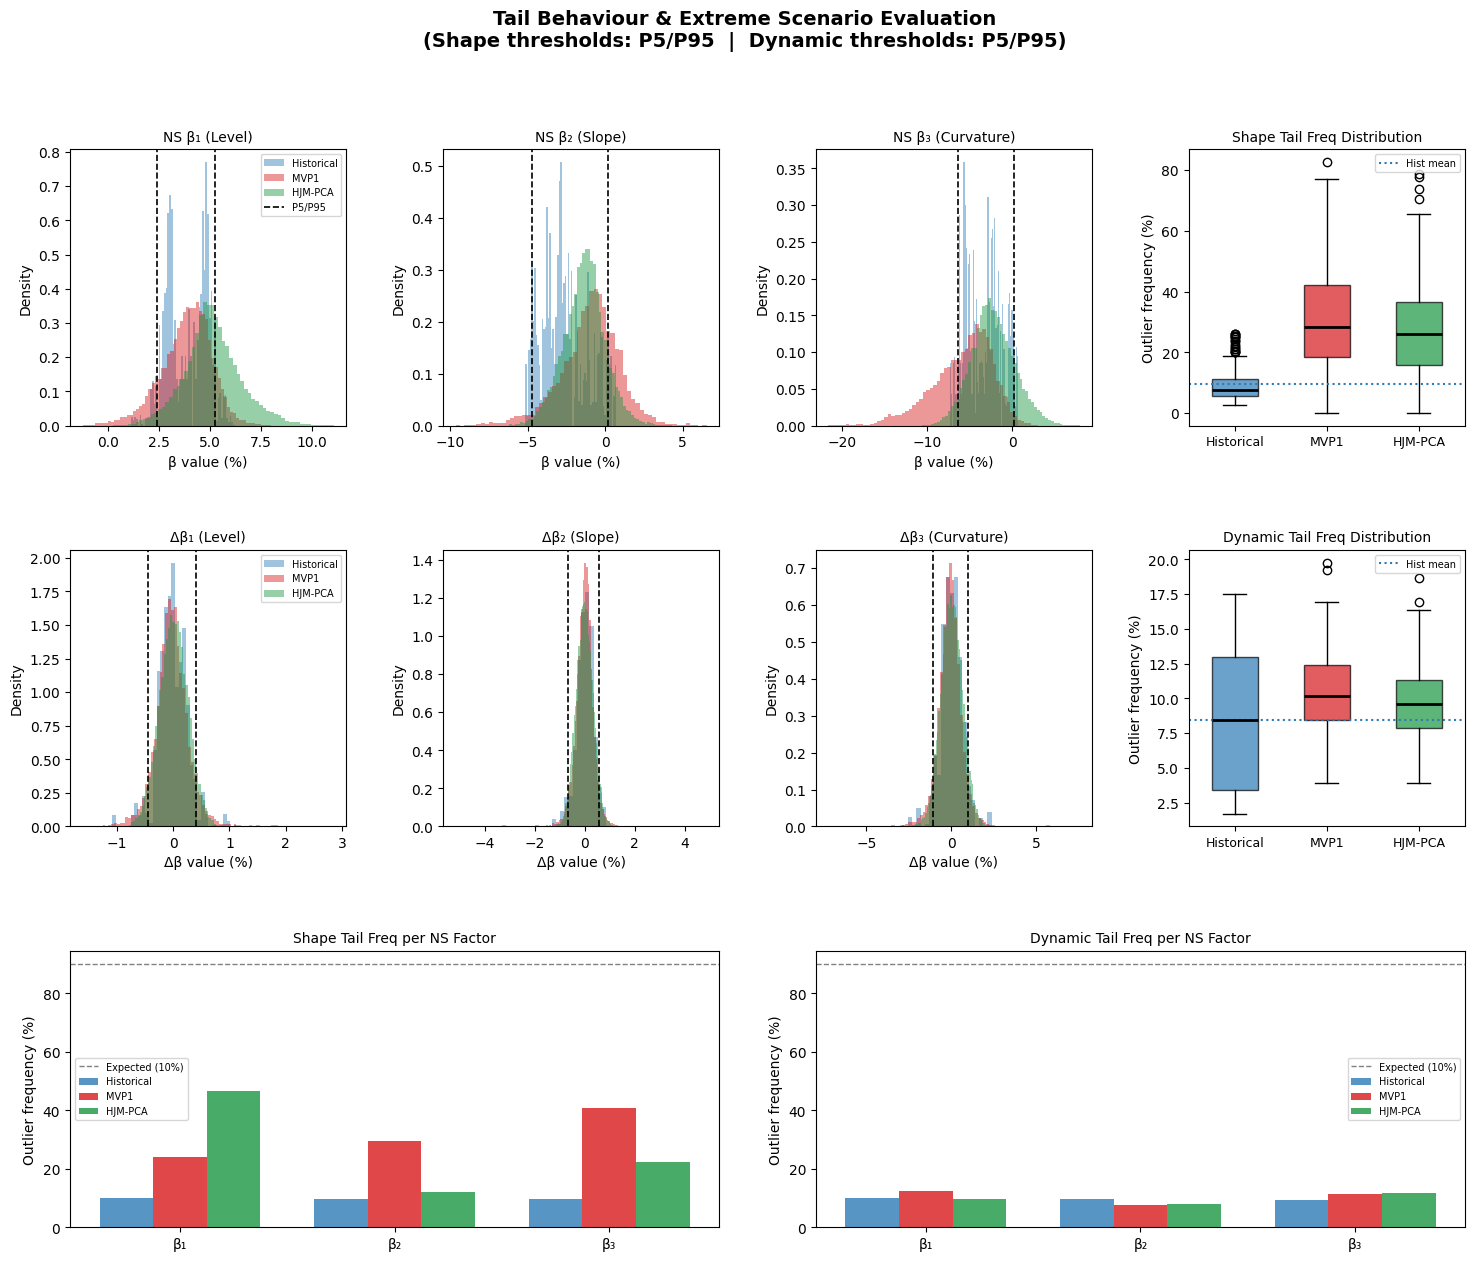


✓ Evaluation complete.


In [35]:
"""
Tail Behaviour & Extreme Scenario Evaluation
=============================================
Evaluates tail behaviour of generated yield curve scenarios (MVP1 and HJM-PCA)
against historical data, following Section 4.7 of the thesis methodology.

Two dimensions are assessed:
  1. Shape-based tail scenarios  – outliers in NS factors (β1, β2, β3)
  2. Dynamic tail scenarios      – extreme first-differences of NS factors

Author: Thesis evaluation pipeline
"""

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# CONFIGURABLE PARAMETERS
# ─────────────────────────────────────────────
SHAPE_LOWER_PCT  = 5    # percentile for lower shape-tail threshold
SHAPE_UPPER_PCT  = 95   # percentile for upper shape-tail threshold
DYNAMIC_LOWER_PCT = 5   # percentile for lower dynamic-tail threshold
DYNAMIC_UPPER_PCT = 95  # percentile for upper dynamic-tail threshold

NS_LAMBDA   = 0.0609    # fixed Nelson-Siegel λ (maturities in months)
WINDOW_SIZE = 60        # rolling window length (months) for historical windows

# Maturity labels and their values in months
MATURITY_LABELS  = ["1M","3M","6M","1Y","2Y","3Y","5Y","7Y","10Y","20Y","30Y"]
MATURITY_MONTHS  = [1, 3, 6, 12, 24, 36, 60, 84, 120, 240, 360]


# ─────────────────────────────────────────────
# NELSON-SIEGEL HELPERS
# ─────────────────────────────────────────────

def ns_loadings(lam: float, maturities: list[float]) -> np.ndarray:
    """
    Compute the (3,) Nelson-Siegel factor loadings for each maturity.
    Returns array of shape (n_maturities, 3): [L1_load, L2_load, L3_load].
    """
    tau = np.array(maturities, dtype=float)
    lt  = lam * tau
    L1  = np.ones_like(tau)
    L2  = (1 - np.exp(-lt)) / lt
    L3  = L2 - np.exp(-lt)
    return np.column_stack([L1, L2, L3])


def fit_ns(yields: np.ndarray, loadings: np.ndarray) -> np.ndarray:
    """
    Fit Nelson-Siegel via OLS to one or many yield curves.

    yields   : (n_curves, n_maturities)  or  (n_maturities,)
    loadings : (n_maturities, 3)
    Returns  : (n_curves, 3)  β = [β1, β2, β3]
    """
    y = np.atleast_2d(yields)
    # OLS: β = (X'X)^{-1} X'y  for each row
    XtX_inv = np.linalg.pinv(loadings.T @ loadings)
    betas = (XtX_inv @ loadings.T @ y.T).T   # (n_curves, 3)
    return betas


# ─────────────────────────────────────────────
# DATA LOADING
# ─────────────────────────────────────────────

def load_historical(path: str) -> np.ndarray:
    """
    Load daily historical data, resample to month-end, extract yield columns.
    Returns array of shape (n_months, 11).
    """
    df = pd.read_csv(path, parse_dates=["DATE"], dayfirst=False)
    df = df.set_index("DATE").sort_index()

    yield_cols = [f"Yield_{m}" for m in MATURITY_LABELS]
    yields_daily = df[yield_cols].dropna()

    # Resample to month-end (last observation of each month)
    yields_monthly = yields_daily.resample("ME").last().dropna()
    print(f"  Historical: {len(yields_daily)} daily → {len(yields_monthly)} monthly obs "
          f"({yields_monthly.index[0].date()} to {yields_monthly.index[-1].date()})")
    return yields_monthly.values   # (n_months, 11)


def load_scenarios(path: str) -> np.ndarray:
    """
    Load generated scenario CSV.
    Returns array of shape (n_scenarios, n_timesteps, n_maturities).
    """
    df = pd.read_csv(path)
    yield_cols = [f"Y_{m}" for m in MATURITY_LABELS]
    n_scen  = df["Scenario_ID"].nunique()
    n_steps = df.groupby("Scenario_ID").size().iloc[0]
    arr = (df.sort_values(["Scenario_ID","Month"])[yield_cols]
             .values
             .reshape(n_scen, n_steps, len(MATURITY_LABELS)))
    print(f"  Scenarios : {n_scen} scenarios × {n_steps} timesteps × {len(MATURITY_LABELS)} maturities")
    return arr   # (200, 60, 11)


# ─────────────────────────────────────────────
# NS FACTOR EXTRACTION
# ─────────────────────────────────────────────

def extract_ns_historical(yields_monthly: np.ndarray,
                          loadings: np.ndarray,
                          window: int = WINDOW_SIZE) -> np.ndarray:
    """
    Extract NS factors for each rolling window of `window` months.
    Each window contributes `window` rows of betas.
    Returns stacked array of shape (n_windows * window, 3).
    """
    n_months = len(yields_monthly)
    all_betas = []
    for start in range(0, n_months - window + 1, 1):   # shift by 1 each time
        chunk = yields_monthly[start : start + window]  # (window, 11)
        betas = fit_ns(chunk, loadings)                 # (window, 3)
        all_betas.append(betas)

    # Stack all windows: (n_windows * window, 3)
    stacked = np.vstack(all_betas)
    print(f"  Historical NS: {len(all_betas)} windows → {stacked.shape[0]} factor obs")
    return stacked, all_betas   # stacked + list of per-window betas


def extract_ns_scenarios(scenarios: np.ndarray,
                         loadings: np.ndarray) -> np.ndarray:
    """
    Extract NS factors for each scenario at each timestep.
    Returns array of shape (n_scenarios, n_timesteps, 3).
    """
    n_scen, n_steps, n_mat = scenarios.shape
    betas = np.zeros((n_scen, n_steps, 3))
    for i in range(n_scen):
        betas[i] = fit_ns(scenarios[i], loadings)   # (n_steps, 3)
    return betas   # (200, 60, 3)


# ─────────────────────────────────────────────
# SHAPE-BASED TAIL ANALYSIS
# ─────────────────────────────────────────────

def shape_tail_thresholds(hist_betas_flat: np.ndarray,
                          lower_pct: float = SHAPE_LOWER_PCT,
                          upper_pct: float = SHAPE_UPPER_PCT) -> dict:
    """
    Compute per-factor (β1, β2, β3) percentile thresholds from historical data.
    hist_betas_flat : (n_obs, 3)
    Returns dict with keys 'lower' and 'upper', each (3,).
    """
    lower = np.percentile(hist_betas_flat, lower_pct, axis=0)
    upper = np.percentile(hist_betas_flat, upper_pct, axis=0)
    return {"lower": lower, "upper": upper}


def compute_shape_outlier_freq(betas: np.ndarray,
                               thresholds: dict) -> np.ndarray:
    """
    For each scenario, compute the proportion of (timestep, factor) observations
    that fall outside [lower, upper] thresholds.

    betas      : (n_scenarios, n_timesteps, 3)
    thresholds : {"lower": (3,), "upper": (3,)}
    Returns    : (n_scenarios,)  – fraction of outlier obs per scenario
    """
    lower = thresholds["lower"]   # (3,)
    upper = thresholds["upper"]   # (3,)
    # Boolean mask: True where outside thresholds
    outlier = (betas < lower[None, None, :]) | (betas > upper[None, None, :])
    # Mean over timesteps and factors for each scenario
    return outlier.mean(axis=(1, 2))   # (n_scenarios,)


def compute_shape_outlier_freq_hist(hist_betas_windows: list,
                                    thresholds: dict) -> np.ndarray:
    """
    Same as above but for historical rolling windows.
    hist_betas_windows : list of (window, 3) arrays
    Returns            : (n_windows,)
    """
    lower = thresholds["lower"]
    upper = thresholds["upper"]
    freqs = []
    for w in hist_betas_windows:
        outlier = (w < lower[None, :]) | (w > upper[None, :])
        freqs.append(outlier.mean())
    return np.array(freqs)


# ─────────────────────────────────────────────
# DYNAMIC TAIL ANALYSIS
# ─────────────────────────────────────────────

def dynamic_tail_thresholds(hist_betas_flat: np.ndarray,
                             lower_pct: float = DYNAMIC_LOWER_PCT,
                             upper_pct: float = DYNAMIC_UPPER_PCT) -> dict:
    """
    Compute per-factor thresholds on absolute first-differences of NS factors.
    Only the largest absolute changes define extreme movements.
    hist_betas_flat : (n_obs, 3)  – already flattened from rolling windows
    Returns dict with 'lower' and 'upper', each (3,).
    """
    # First differences (across all flattened obs – approximation for threshold)
    diffs = np.diff(hist_betas_flat, axis=0)   # (n_obs-1, 3)
    # Thresholds on absolute differences
    lower = np.percentile(diffs, lower_pct, axis=0)
    upper = np.percentile(diffs, upper_pct, axis=0)
    return {"lower": lower, "upper": upper, "diffs_hist": diffs}


def compute_dynamic_outlier_freq(betas: np.ndarray,
                                 thresholds: dict) -> np.ndarray:
    """
    For each scenario, compute first-differences of betas and find proportion
    of (timestep, factor) observations outside [lower, upper].

    betas   : (n_scenarios, n_timesteps, 3)
    Returns : (n_scenarios,)
    """
    lower = thresholds["lower"]
    upper = thresholds["upper"]
    diffs = np.diff(betas, axis=1)   # (n_scenarios, n_timesteps-1, 3)
    outlier = (diffs < lower[None, None, :]) | (diffs > upper[None, None, :])
    return outlier.mean(axis=(1, 2))


def compute_dynamic_outlier_freq_hist(hist_betas_windows: list,
                                      thresholds: dict) -> np.ndarray:
    """
    Dynamic outlier frequency for historical rolling windows.
    """
    lower = thresholds["lower"]
    upper = thresholds["upper"]
    freqs = []
    for w in hist_betas_windows:
        diffs = np.diff(w, axis=0)   # (window-1, 3)
        outlier = (diffs < lower[None, :]) | (diffs > upper[None, :])
        freqs.append(outlier.mean())
    return np.array(freqs)


# ─────────────────────────────────────────────
# SUMMARY TABLE
# ─────────────────────────────────────────────

def build_summary_table(
        hist_shape_freq  : np.ndarray,
        mvp1_shape_freq  : np.ndarray,
        hjm_shape_freq   : np.ndarray,
        hist_dyn_freq    : np.ndarray,
        mvp1_dyn_freq    : np.ndarray,
        hjm_dyn_freq     : np.ndarray,
) -> pd.DataFrame:
    """
    Build a compact summary table comparing all three datasets.
    """
    def summarise(arr):
        return {
            "Mean freq (%)": arr.mean() * 100,
            "Std (%)":       arr.std()  * 100,
            "Median (%)":    np.median(arr) * 100,
            "P5 (%)":        np.percentile(arr, 5)  * 100,
            "P95 (%)":       np.percentile(arr, 95) * 100,
        }

    rows = {}
    for label, arr in [("Historical", hist_shape_freq),
                        ("MVP1",       mvp1_shape_freq),
                        ("HJM-PCA",    hjm_shape_freq)]:
        rows[label] = summarise(arr)
    shape_df = pd.DataFrame(rows).T

    rows2 = {}
    for label, arr in [("Historical", hist_dyn_freq),
                        ("MVP1",       mvp1_dyn_freq),
                        ("HJM-PCA",    hjm_dyn_freq)]:
        rows2[label] = summarise(arr)
    dyn_df = pd.DataFrame(rows2).T

    return shape_df, dyn_df


def print_tables(shape_df, dyn_df):
    pd.set_option("display.float_format", "{:.3f}".format)
    print("\n" + "="*65)
    print("  SHAPE-BASED TAIL FREQUENCY  "
          f"(thresholds: P{SHAPE_LOWER_PCT}/P{SHAPE_UPPER_PCT} of historical NS factors)")
    print("  % of (timestep × factor) observations outside thresholds")
    print("="*65)
    print(shape_df.to_string())
    print("\n" + "="*65)
    print("  DYNAMIC TAIL FREQUENCY  "
          f"(thresholds: P{DYNAMIC_LOWER_PCT}/P{DYNAMIC_UPPER_PCT} of historical ΔNS factors)")
    print("  % of (timestep × factor) first-differences outside thresholds")
    print("="*65)
    print(dyn_df.to_string())


# ─────────────────────────────────────────────
# PLOTTING
# ─────────────────────────────────────────────

COLORS = {"Historical": "#2c7bb6", "MVP1": "#d7191c", "HJM-PCA": "#1a9641"}

def plot_tail_results(
        hist_shape_freq, mvp1_shape_freq, hjm_shape_freq,
        hist_dyn_freq,   mvp1_dyn_freq,   hjm_dyn_freq,
        hist_betas_flat, mvp1_betas, hjm_betas,
        shape_thresholds, dyn_thresholds,
        save_path: str = None
):
    fig = plt.figure(figsize=(18, 14))
    fig.suptitle("Tail Behaviour & Extreme Scenario Evaluation\n"
                 f"(Shape thresholds: P{SHAPE_LOWER_PCT}/P{SHAPE_UPPER_PCT}  |  "
                 f"Dynamic thresholds: P{DYNAMIC_LOWER_PCT}/P{DYNAMIC_UPPER_PCT})",
                 fontsize=14, fontweight="bold", y=0.98)

    gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)

    # ── Row 0: NS factor distributions (historical vs generated) ──────────
    factor_names = ["β₁ (Level)", "β₂ (Slope)", "β₃ (Curvature)"]
    mvp1_flat = mvp1_betas.reshape(-1, 3)   # (200*60, 3)
    hjm_flat  = hjm_betas.reshape(-1, 3)

    for f in range(3):
        ax = fig.add_subplot(gs[0, f])
        lo, hi = shape_thresholds["lower"][f], shape_thresholds["upper"][f]
        for label, arr, c in [("Historical", hist_betas_flat[:, f], COLORS["Historical"]),
                               ("MVP1",       mvp1_flat[:, f],       COLORS["MVP1"]),
                               ("HJM-PCA",    hjm_flat[:, f],        COLORS["HJM-PCA"])]:
            ax.hist(arr, bins=60, density=True, alpha=0.45, color=c, label=label)
        ax.axvline(lo, color="black", ls="--", lw=1.2, label=f"P{SHAPE_LOWER_PCT}/P{SHAPE_UPPER_PCT}")
        ax.axvline(hi, color="black", ls="--", lw=1.2)
        ax.set_title(f"NS {factor_names[f]}", fontsize=10)
        ax.set_xlabel("β value (%)")
        ax.set_ylabel("Density")
        if f == 0:
            ax.legend(fontsize=7)

    # ── Row 0, col 3: Shape tail frequency box plot ───────────────────────
    ax_box1 = fig.add_subplot(gs[0, 3])
    data_shape = [hist_shape_freq * 100, mvp1_shape_freq * 100, hjm_shape_freq * 100]
    bp1 = ax_box1.boxplot(data_shape, patch_artist=True, widths=0.5,
                          medianprops=dict(color="black", lw=2))
    for patch, c in zip(bp1["boxes"], COLORS.values()):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    ax_box1.set_xticks([1, 2, 3])
    ax_box1.set_xticklabels(["Historical", "MVP1", "HJM-PCA"], fontsize=9)
    ax_box1.set_ylabel("Outlier frequency (%)")
    ax_box1.set_title("Shape Tail Freq Distribution", fontsize=10)
    ax_box1.axhline(hist_shape_freq.mean() * 100, color=COLORS["Historical"],
                    ls=":", lw=1.5, label="Hist mean")
    ax_box1.legend(fontsize=7)

    # ── Row 1: Δβ distributions ───────────────────────────────────────────
    mvp1_diffs = np.diff(mvp1_betas, axis=1).reshape(-1, 3)
    hjm_diffs  = np.diff(hjm_betas,  axis=1).reshape(-1, 3)
    hist_diffs = dyn_thresholds["diffs_hist"]

    for f in range(3):
        ax = fig.add_subplot(gs[1, f])
        lo, hi = dyn_thresholds["lower"][f], dyn_thresholds["upper"][f]
        for label, arr, c in [("Historical", hist_diffs[:, f], COLORS["Historical"]),
                               ("MVP1",       mvp1_diffs[:, f], COLORS["MVP1"]),
                               ("HJM-PCA",    hjm_diffs[:, f],  COLORS["HJM-PCA"])]:
            ax.hist(arr, bins=60, density=True, alpha=0.45, color=c, label=label)
        ax.axvline(lo, color="black", ls="--", lw=1.2)
        ax.axvline(hi, color="black", ls="--", lw=1.2)
        ax.set_title(f"Δ{factor_names[f]}", fontsize=10)
        ax.set_xlabel("Δβ value (%)")
        ax.set_ylabel("Density")
        if f == 0:
            ax.legend(fontsize=7)

    # ── Row 1, col 3: Dynamic tail frequency box plot ─────────────────────
    ax_box2 = fig.add_subplot(gs[1, 3])
    data_dyn = [hist_dyn_freq * 100, mvp1_dyn_freq * 100, hjm_dyn_freq * 100]
    bp2 = ax_box2.boxplot(data_dyn, patch_artist=True, widths=0.5,
                          medianprops=dict(color="black", lw=2))
    for patch, c in zip(bp2["boxes"], COLORS.values()):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    ax_box2.set_xticks([1, 2, 3])
    ax_box2.set_xticklabels(["Historical", "MVP1", "HJM-PCA"], fontsize=9)
    ax_box2.set_ylabel("Outlier frequency (%)")
    ax_box2.set_title("Dynamic Tail Freq Distribution", fontsize=10)
    ax_box2.axhline(hist_dyn_freq.mean() * 100, color=COLORS["Historical"],
                    ls=":", lw=1.5, label="Hist mean")
    ax_box2.legend(fontsize=7)

    # ── Row 2: Mean outlier frequency per factor (shape & dynamic) ────────
    factor_short = ["β₁", "β₂", "β₃"]

    # Per-factor shape outlier freq
    ax_f1 = fig.add_subplot(gs[2, :2])
    width = 0.25
    x = np.arange(3)
    for i, (label, betas_arr, c) in enumerate([
            ("Historical", hist_betas_flat, COLORS["Historical"]),
            ("MVP1",       mvp1_flat,        COLORS["MVP1"]),
            ("HJM-PCA",    hjm_flat,         COLORS["HJM-PCA"])]):
        lo = shape_thresholds["lower"]
        hi = shape_thresholds["upper"]
        per_factor = []
        for f in range(3):
            out = ((betas_arr[:, f] < lo[f]) | (betas_arr[:, f] > hi[f])).mean()
            per_factor.append(out * 100)
        ax_f1.bar(x + i * width, per_factor, width, label=label, color=c, alpha=0.8)
    ax_f1.set_xticks(x + width)
    ax_f1.set_xticklabels(factor_short)
    ax_f1.set_ylabel("Outlier frequency (%)")
    ax_f1.set_title("Shape Tail Freq per NS Factor", fontsize=10)
    ax_f1.axhline((SHAPE_UPPER_PCT - SHAPE_LOWER_PCT) / 100 * 100 / 1,
                  color="grey", ls="--", lw=1, label="Expected (10%)")
    ax_f1.legend(fontsize=7)

    # Per-factor dynamic outlier freq
    ax_f2 = fig.add_subplot(gs[2, 2:])
    for i, (label, diffs_arr, c) in enumerate([
            ("Historical", hist_diffs,  COLORS["Historical"]),
            ("MVP1",       mvp1_diffs,  COLORS["MVP1"]),
            ("HJM-PCA",    hjm_diffs,   COLORS["HJM-PCA"])]):
        lo = dyn_thresholds["lower"]
        hi = dyn_thresholds["upper"]
        per_factor = []
        for f in range(3):
            out = ((diffs_arr[:, f] < lo[f]) | (diffs_arr[:, f] > hi[f])).mean()
            per_factor.append(out * 100)
        ax_f2.bar(x + i * width, per_factor, width, label=label, color=c, alpha=0.8)
    ax_f2.set_xticks(x + width)
    ax_f2.set_xticklabels(factor_short)
    ax_f2.set_ylabel("Outlier frequency (%)")
    ax_f2.set_title("Dynamic Tail Freq per NS Factor", fontsize=10)
    ax_f2.axhline((DYNAMIC_UPPER_PCT - DYNAMIC_LOWER_PCT) / 100 * 100 / 1,
                  color="grey", ls="--", lw=1, label="Expected (10%)")
    ax_f2.legend(fontsize=7)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"\n  Figure saved → {save_path}")
    plt.show()


# ─────────────────────────────────────────────
# STATISTICAL COMPARISON
# ─────────────────────────────────────────────

def t_test_comparison(freq_a: np.ndarray, freq_b: np.ndarray,
                       label_a: str, label_b: str) -> dict:
    """
    Welch's two-sample t-test: H0: mean(A) == mean(B).
    Returns dict with t-stat, p-value, and interpretation.
    """
    t_stat, p_val = stats.ttest_ind(freq_a, freq_b, equal_var=False)
    D = freq_b.mean() - freq_a.mean()
    result = {
        "D (B-A mean diff %)": D * 100,
        "t-statistic":          t_stat,
        "p-value":              p_val,
        "Significant (5%)":     p_val < 0.05,
        "Better model":         label_a if D > 0 else label_b,
    }
    return result


def print_stat_tests(hist_shape, mvp1_shape, hjm_shape,
                     hist_dyn,   mvp1_dyn,   hjm_dyn):
    print("\n" + "="*65)
    print("  STATISTICAL TESTS  (Welch's t-test, α=0.05)")
    print("  A positive D means model A has lower freq → better")
    print("="*65)

    tests = [
        ("Shape",   "Historical", "MVP1",    hist_shape, mvp1_shape),
        ("Shape",   "Historical", "HJM-PCA", hist_shape, hjm_shape),
        ("Shape",   "MVP1",       "HJM-PCA", mvp1_shape, hjm_shape),
        ("Dynamic", "Historical", "MVP1",    hist_dyn,   mvp1_dyn),
        ("Dynamic", "Historical", "HJM-PCA", hist_dyn,   hjm_dyn),
        ("Dynamic", "MVP1",       "HJM-PCA", mvp1_dyn,   hjm_dyn),
    ]
    rows = []
    for kind, la, lb, a, b in tests:
        r = t_test_comparison(a, b, la, lb)
        rows.append({
            "Type": kind, "Model A": la, "Model B": lb,
            **r
        })
    df = pd.DataFrame(rows).set_index(["Type","Model A","Model B"])
    print(df.to_string(float_format="{:.4f}".format))


# ─────────────────────────────────────────────
# MAIN PIPELINE
# ─────────────────────────────────────────────

def main():
    print("\n" + "="*65)
    print("  TAIL BEHAVIOUR & EXTREME SCENARIO EVALUATION")
    print("="*65)

    # 1. Load data ───────────────────────────────────────────────────────
    print("\n[1] Loading data...")
    yields_monthly = load_historical(historical_data)
    mvp1_scenarios = load_scenarios(current_diffusion)
    hjm_scenarios  = load_scenarios(hjm_data)
    

    # 2. Nelson-Siegel loadings ──────────────────────────────────────────
    print("\n[2] Computing Nelson-Siegel loadings (λ={})...".format(NS_LAMBDA))
    loadings = ns_loadings(NS_LAMBDA, MATURITY_MONTHS)   # (11, 3)

    # 3. Extract NS factors ──────────────────────────────────────────────
    print("\n[3] Extracting NS factors...")
    print("  Historical rolling windows:")
    hist_betas_flat, hist_betas_windows = extract_ns_historical(
        yields_monthly, loadings, WINDOW_SIZE)
    print("  MVP1 scenarios:")
    mvp1_betas = extract_ns_scenarios(mvp1_scenarios, loadings)  # (200,60,3)
    print("  HJM-PCA scenarios:")
    hjm_betas  = extract_ns_scenarios(hjm_scenarios,  loadings)  # (200,60,3)

    # 4. Shape-based tail thresholds (from historical) ───────────────────
    print("\n[4] Computing shape-based tail thresholds from historical NS factors...")
    shape_thresh = shape_tail_thresholds(hist_betas_flat,
                                         SHAPE_LOWER_PCT, SHAPE_UPPER_PCT)
    for f, name in enumerate(["β1 (Level)", "β2 (Slope)", "β3 (Curvature)"]):
        print(f"  {name}: [{shape_thresh['lower'][f]:.4f}, "
              f"{shape_thresh['upper'][f]:.4f}]")

    # 5. Shape outlier frequencies ───────────────────────────────────────
    print("\n[5] Computing shape-based outlier frequencies...")
    hist_shape_freq = compute_shape_outlier_freq_hist(hist_betas_windows, shape_thresh)
    mvp1_shape_freq = compute_shape_outlier_freq(mvp1_betas, shape_thresh)
    hjm_shape_freq  = compute_shape_outlier_freq(hjm_betas,  shape_thresh)

    # 6. Dynamic tail thresholds (from historical Δβ) ────────────────────
    print("\n[6] Computing dynamic tail thresholds from historical Δβ...")
    dyn_thresh = dynamic_tail_thresholds(hist_betas_flat,
                                         DYNAMIC_LOWER_PCT, DYNAMIC_UPPER_PCT)
    for f, name in enumerate(["Δβ1", "Δβ2", "Δβ3"]):
        print(f"  {name}: [{dyn_thresh['lower'][f]:.4f}, "
              f"{dyn_thresh['upper'][f]:.4f}]")

    # 7. Dynamic outlier frequencies ─────────────────────────────────────
    print("\n[7] Computing dynamic outlier frequencies...")
    hist_dyn_freq = compute_dynamic_outlier_freq_hist(hist_betas_windows, dyn_thresh)
    mvp1_dyn_freq = compute_dynamic_outlier_freq(mvp1_betas, dyn_thresh)
    hjm_dyn_freq  = compute_dynamic_outlier_freq(hjm_betas,  dyn_thresh)

    # 8. Summary tables ──────────────────────────────────────────────────
    print("\n[8] Building summary tables...")
    shape_df, dyn_df = build_summary_table(
        hist_shape_freq, mvp1_shape_freq, hjm_shape_freq,
        hist_dyn_freq,   mvp1_dyn_freq,   hjm_dyn_freq)
    print_tables(shape_df, dyn_df)

    # 9. Statistical tests ───────────────────────────────────────────────
    print("\n[9] Running statistical comparisons...")
    print_stat_tests(hist_shape_freq, mvp1_shape_freq, hjm_shape_freq,
                     hist_dyn_freq,   mvp1_dyn_freq,   hjm_dyn_freq)

    # 10. Plot ───────────────────────────────────────────────────────────
    print("\n[10] Generating plots...")
    plot_tail_results(
        hist_shape_freq, mvp1_shape_freq, hjm_shape_freq,
        hist_dyn_freq,   mvp1_dyn_freq,   hjm_dyn_freq,
        hist_betas_flat, mvp1_betas, hjm_betas,
        shape_thresh, dyn_thresh
    )

    print("\n✓ Evaluation complete.")
    return {
        "shape_summary": shape_df,
        "dynamic_summary": dyn_df,
        "shape_thresholds": shape_thresh,
        "dynamic_thresholds": dyn_thresh,
        "hist_shape_freq": hist_shape_freq,
        "mvp1_shape_freq": mvp1_shape_freq,
        "hjm_shape_freq":  hjm_shape_freq,
        "hist_dyn_freq":   hist_dyn_freq,
        "mvp1_dyn_freq":   mvp1_dyn_freq,
        "hjm_dyn_freq":    hjm_dyn_freq,
    }


if __name__ == "__main__":
    results = main()

### Novelty


  NOVELTY EVALUATION

[1] Loading data...
  Historical: 232 monthly obs → 173 rolling windows of 60
  Scenarios: 200 scenarios × 60 timesteps × 11 maturities
  Scenarios: 500 scenarios × 60 timesteps × 11 maturities

[2] Calibrating thresholds (historical nearest-neighbour distances)...

  Historical nearest-neighbour distance distribution:
    P 5: 0.0736 pp
    P10: 0.1220 pp
    P25: 0.1696 pp
    P50: 0.2666 pp
    P75: 0.3811 pp
    P90: 0.5406 pp
    P95: 0.6452 pp
    P99: 1.0463 pp
    Mean: 0.3043 pp  |  Std: 0.1951 pp

  → Current thresholds:  lower=0.5  upper=4.0

[3] Computing min distances to historical set...
  Historical windows: 10380 obs
  MVP1: 12000 obs
  HJM-PCA: 30000 obs

[4] Classifying observations...

[5] Computing per-scenario novelty frequencies...
  Historical windows:
  MVP1:
  HJM-PCA:

[6] Building summary tables...

  OBSERVATION-LEVEL NOVELTY  (lower=0.5, upper=4.0)
  All timestep observations pooled across scenarios
            Not Novel (%)  Novel (%

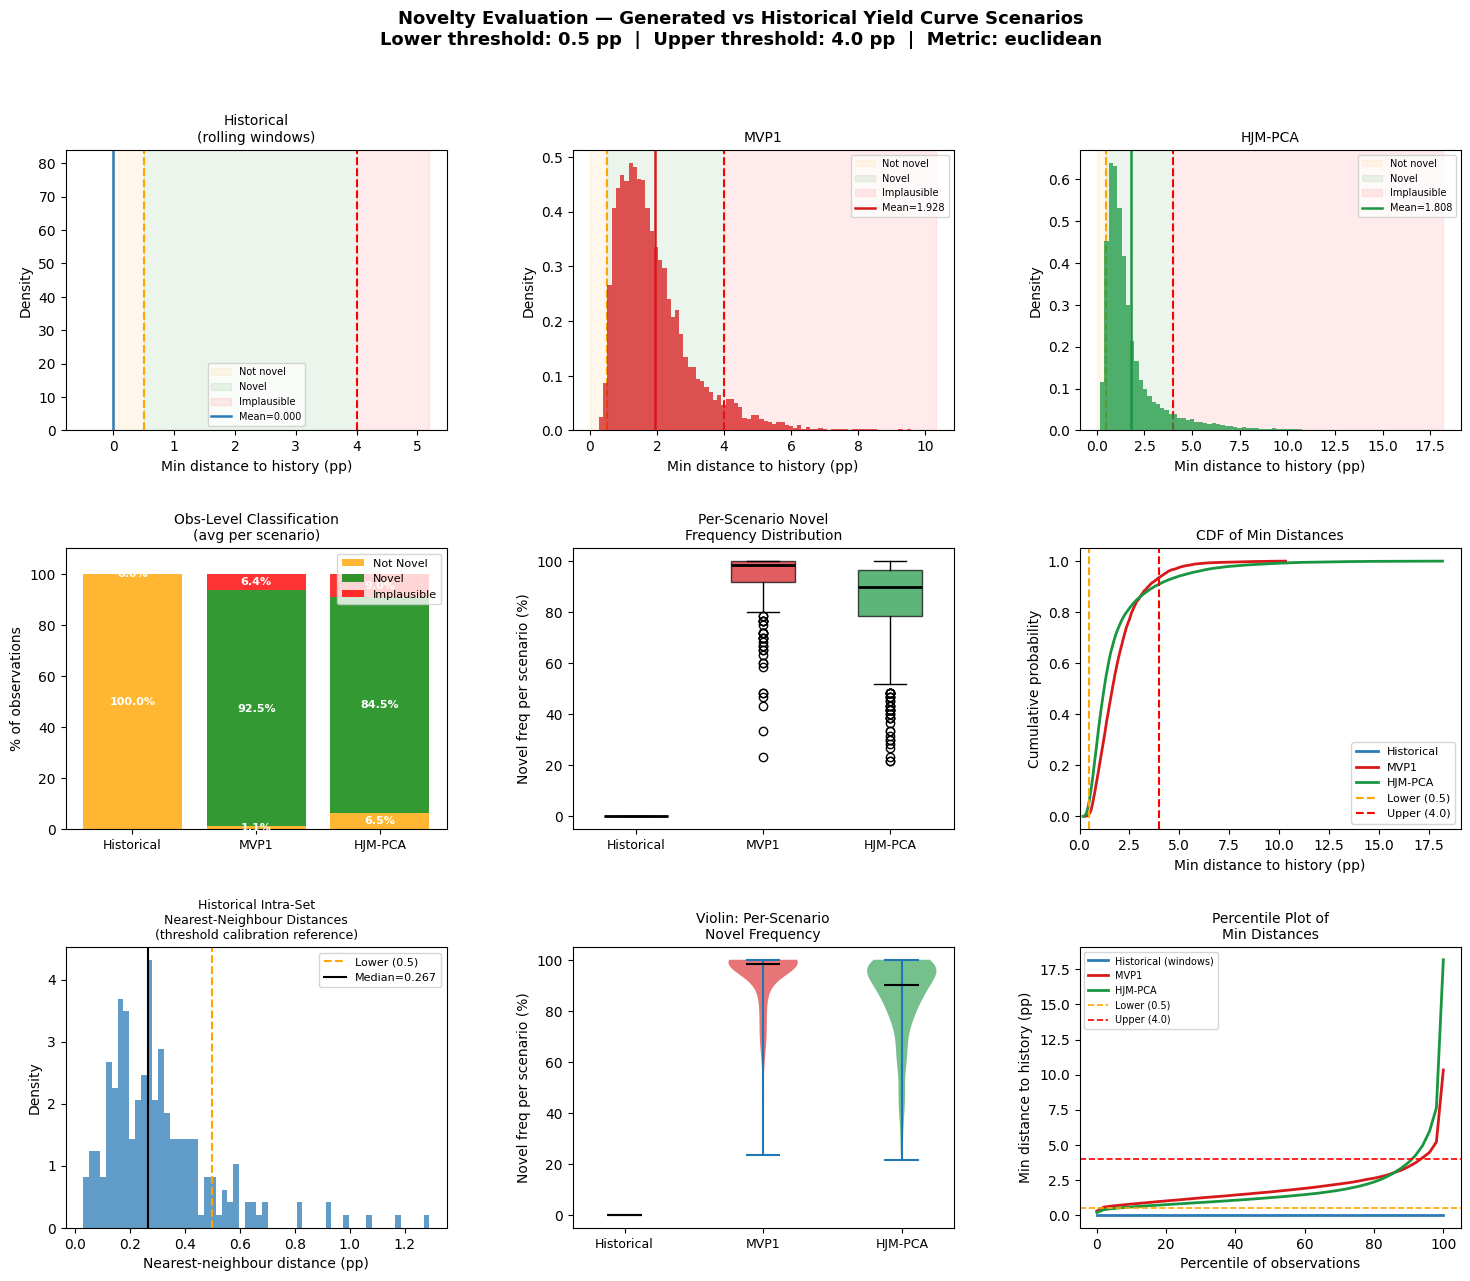


✓ Novelty evaluation complete.


In [36]:
"""
Novelty Evaluation
==================
Assesses the novelty of generated yield curve scenarios (MVP1 and HJM-PCA)
relative to the historical dataset, following Section 4.7 (Novelty) of the
thesis methodology.

A generated yield curve observation is classified as:
  - Too close   : min_distance < NOVELTY_LOWER_THRESHOLD  (not novel, replicates history)
  - Novel       : NOVELTY_LOWER_THRESHOLD <= min_distance <= NOVELTY_UPPER_THRESHOLD
  - Implausible : min_distance > NOVELTY_UPPER_THRESHOLD  (too far from history)

Distances are computed as the Euclidean distance between yield curve vectors
(in percentage points, across all 11 maturities).

Author: Thesis evaluation pipeline
"""

import numpy as np
import pandas as pd
from scipy import stats
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# CONFIGURABLE PARAMETERS
# ─────────────────────────────────────────────

# Distance thresholds (Euclidean, in percentage points across 11 maturities)
# Lower: below this → not novel (too similar to history)
# Upper: above this → implausible (too far from history)
# Calibrated on the observed historical pairwise distance distribution:
#   typical neighbour distances range ~0.3 to ~4.0 pp
NOVELTY_LOWER_THRESHOLD = 0.50   # pp  — adjust as needed
NOVELTY_UPPER_THRESHOLD = 4.00   # pp  — adjust as needed

DISTANCE_METRIC = "euclidean"    # distance metric for cdist

# Maturity labels (must match column order in all CSVs)
MATURITY_LABELS = ["1M","3M","6M","1Y","2Y","3Y","5Y","7Y","10Y","20Y","30Y"]


# ─────────────────────────────────────────────
# DATA LOADING  (reusing same logic as tail_evaluation.py)
# ─────────────────────────────────────────────

def load_historical(path: str) -> tuple[np.ndarray, np.ndarray]:
    """
    Load daily historical data, resample to month-end, extract yield columns.
    Returns:
        yields_monthly : (n_months, 11)  – used as reference set
        rolling_windows: (n_windows, 60, 11) – comparable 60-step windows
    """
    df = pd.read_csv(path, parse_dates=["DATE"], dayfirst=False)
    df = df.set_index("DATE").sort_index()
    yield_cols = [f"Yield_{m}" for m in MATURITY_LABELS]
    yields_monthly = df[yield_cols].dropna().resample("ME").last().dropna().values

    # Build rolling windows of 60 timesteps (shift by 1 each time)
    W = 60
    n = len(yields_monthly)
    windows = np.stack([yields_monthly[s:s+W] for s in range(n - W + 1)])
    print(f"  Historical: {n} monthly obs → {len(windows)} rolling windows of {W}")
    return yields_monthly, windows   # (n_months,11) and (n_windows,60,11)


def load_scenarios(path: str) -> np.ndarray:
    """
    Load generated scenario CSV.
    Returns array of shape (n_scenarios, n_timesteps, n_maturities).
    """
    df = pd.read_csv(path)
    yield_cols = [f"Y_{m}" for m in MATURITY_LABELS]
    n_scen  = df["Scenario_ID"].nunique()
    n_steps = df.groupby("Scenario_ID").size().iloc[0]
    arr = (df.sort_values(["Scenario_ID","Month"])[yield_cols]
             .values
             .reshape(n_scen, n_steps, len(MATURITY_LABELS)))
    print(f"  Scenarios: {n_scen} scenarios × {n_steps} timesteps × {len(MATURITY_LABELS)} maturities")
    return arr


# ─────────────────────────────────────────────
# DISTANCE COMPUTATION
# ─────────────────────────────────────────────

def min_distance_to_history(generated_obs: np.ndarray,
                             historical_obs: np.ndarray,
                             metric: str = DISTANCE_METRIC) -> np.ndarray:
    """
    For each generated yield curve observation, compute the minimum Euclidean
    distance to any yield curve in the historical dataset.

    generated_obs : (N, 11)  – all generated observations (flattened across scenarios)
    historical_obs: (M, 11)  – all historical monthly observations
    Returns       : (N,)     – min distance for each generated observation
    """
    # cdist returns (N, M); take row-wise min
    D = cdist(generated_obs, historical_obs, metric=metric)
    return D.min(axis=1)   # (N,)


def classify_observations(min_dists: np.ndarray,
                           lower: float = NOVELTY_LOWER_THRESHOLD,
                           upper: float = NOVELTY_UPPER_THRESHOLD
                           ) -> dict:
    """
    Classify each observation as not-novel, novel, or implausible.
    Returns dict with boolean masks and summary proportions.
    """
    not_novel   = min_dists < lower
    novel       = (min_dists >= lower) & (min_dists <= upper)
    implausible = min_dists > upper

    n = len(min_dists)
    return {
        "not_novel_mask":   not_novel,
        "novel_mask":       novel,
        "implausible_mask": implausible,
        "pct_not_novel":    not_novel.mean()   * 100,
        "pct_novel":        novel.mean()       * 100,
        "pct_implausible":  implausible.mean() * 100,
        "mean_min_dist":    min_dists.mean(),
        "median_min_dist":  np.median(min_dists),
        "p5_min_dist":      np.percentile(min_dists, 5),
        "p95_min_dist":     np.percentile(min_dists, 95),
        "n_obs":            n,
    }


# ─────────────────────────────────────────────
# SCENARIO-LEVEL NOVELTY
# ─────────────────────────────────────────────

def scenario_novelty_freq(scenarios: np.ndarray,
                           historical_obs: np.ndarray,
                           lower: float = NOVELTY_LOWER_THRESHOLD,
                           upper: float = NOVELTY_UPPER_THRESHOLD
                           ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    For each scenario, compute the proportion of its timestep observations
    that are classified as novel, not-novel, and implausible.

    scenarios     : (n_scenarios, n_timesteps, 11)
    historical_obs: (M, 11)
    Returns three arrays of shape (n_scenarios,): novel_freq, not_novel_freq, implausible_freq
    """
    n_scen, n_steps, n_mat = scenarios.shape
    novel_freq       = np.zeros(n_scen)
    not_novel_freq   = np.zeros(n_scen)
    implausible_freq = np.zeros(n_scen)

    for i in range(n_scen):
        obs = scenarios[i]   # (n_steps, 11)
        dists = min_distance_to_history(obs, historical_obs)
        cl = classify_observations(dists, lower, upper)
        novel_freq[i]       = cl["pct_novel"]
        not_novel_freq[i]   = cl["pct_not_novel"]
        implausible_freq[i] = cl["pct_implausible"]

    return novel_freq, not_novel_freq, implausible_freq


def window_novelty_freq(windows: np.ndarray,
                         historical_obs: np.ndarray,
                         lower: float = NOVELTY_LOWER_THRESHOLD,
                         upper: float = NOVELTY_UPPER_THRESHOLD
                         ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Same as scenario_novelty_freq but for historical rolling windows.
    Each window is compared against the FULL historical set (including itself),
    giving a baseline of how often historical obs are "novel" to themselves.

    windows       : (n_windows, 60, 11)
    historical_obs: (M, 11)
    """
    n_windows = len(windows)
    novel_freq       = np.zeros(n_windows)
    not_novel_freq   = np.zeros(n_windows)
    implausible_freq = np.zeros(n_windows)

    for i in range(n_windows):
        obs = windows[i]   # (60, 11)
        dists = min_distance_to_history(obs, historical_obs)
        cl = classify_observations(dists, lower, upper)
        novel_freq[i]       = cl["pct_novel"]
        not_novel_freq[i]   = cl["pct_not_novel"]
        implausible_freq[i] = cl["pct_implausible"]

    return novel_freq, not_novel_freq, implausible_freq


# ─────────────────────────────────────────────
# CALIBRATION HELPER
# ─────────────────────────────────────────────

def calibrate_thresholds(historical_obs: np.ndarray, sample_size: int = 500):
    """
    Print pairwise distance percentiles within the historical dataset to help
    the user calibrate NOVELTY_LOWER_THRESHOLD and NOVELTY_UPPER_THRESHOLD.
    Uses a random subsample for efficiency if the dataset is large.
    """
    n = len(historical_obs)
    if n > sample_size:
        idx = np.random.choice(n, sample_size, replace=False)
        sample = historical_obs[idx]
    else:
        sample = historical_obs

    D = cdist(sample, sample, metric=DISTANCE_METRIC)
    # Zero out diagonal (self-distances)
    np.fill_diagonal(D, np.inf)
    nn_dists = D.min(axis=1)   # nearest-neighbour distances within history

    print("\n  Historical nearest-neighbour distance distribution:")
    for p in [5, 10, 25, 50, 75, 90, 95, 99]:
        print(f"    P{p:2d}: {np.percentile(nn_dists, p):.4f} pp")
    print(f"    Mean: {nn_dists.mean():.4f} pp  |  Std: {nn_dists.std():.4f} pp")
    print(f"\n  → Current thresholds:  lower={NOVELTY_LOWER_THRESHOLD}  "
          f"upper={NOVELTY_UPPER_THRESHOLD}")
    return nn_dists


# ─────────────────────────────────────────────
# SUMMARY TABLE
# ─────────────────────────────────────────────

def build_summary_table(results: dict) -> pd.DataFrame:
    """
    Build a comparison table of novelty metrics across models.
    results: dict keyed by model name, each containing classify_observations output
    """
    rows = {}
    for model, r in results.items():
        rows[model] = {
            "Not Novel (%)":   r["pct_not_novel"],
            "Novel (%)":       r["pct_novel"],
            "Implausible (%)": r["pct_implausible"],
            "Mean min dist":   r["mean_min_dist"],
            "Median min dist": r["median_min_dist"],
            "P5 min dist":     r["p5_min_dist"],
            "P95 min dist":    r["p95_min_dist"],
        }
    return pd.DataFrame(rows).T


def build_scenario_table(
        hist_novel, hist_not_novel, hist_implausible,
        mvp1_novel, mvp1_not_novel, mvp1_implausible,
        hjm_novel,  hjm_not_novel,  hjm_implausible,
) -> pd.DataFrame:
    """Summary table of per-scenario novelty frequencies."""
    def row(novel, not_novel, implausible):
        return {
            "Mean novel (%)":       novel.mean(),
            "Std novel (%)":        novel.std(),
            "Median novel (%)":     np.median(novel),
            "P5 novel (%)":         np.percentile(novel, 5),
            "P95 novel (%)":        np.percentile(novel, 95),
            "Mean implausible (%)": implausible.mean(),
        }
    return pd.DataFrame({
        "Historical": row(hist_novel, hist_not_novel, hist_implausible),
        "MVP1":       row(mvp1_novel, mvp1_not_novel, mvp1_implausible),
        "HJM-PCA":   row(hjm_novel,  hjm_not_novel,  hjm_implausible),
    }).T


def print_tables(obs_table, scen_table):
    pd.set_option("display.float_format", "{:.3f}".format)
    print("\n" + "="*70)
    print("  OBSERVATION-LEVEL NOVELTY  "
          f"(lower={NOVELTY_LOWER_THRESHOLD}, upper={NOVELTY_UPPER_THRESHOLD})")
    print("  All timestep observations pooled across scenarios")
    print("="*70)
    print(obs_table.to_string())

    print("\n" + "="*70)
    print("  SCENARIO-LEVEL NOVELTY  (per-scenario mean novelty freq)")
    print("="*70)
    print(scen_table.to_string())


# ─────────────────────────────────────────────
# STATISTICAL TESTS
# ─────────────────────────────────────────────

def t_test(a: np.ndarray, b: np.ndarray, label_a: str, label_b: str) -> dict:
    t_stat, p_val = stats.ttest_ind(a, b, equal_var=False)
    D = b.mean() - a.mean()
    return {
        "D (B−A, %)": D,
        "t-statistic": t_stat,
        "p-value":     p_val,
        "Significant": p_val < 0.05,
        "Higher novel": label_b if D > 0 else label_a,
    }


def print_stat_tests(hist_novel, mvp1_novel, hjm_novel):
    print("\n" + "="*70)
    print("  STATISTICAL TESTS on novel frequency  (Welch's t-test, α=0.05)")
    print("  Positive D → model B has higher novelty frequency")
    print("="*70)
    tests = [
        ("Historical", "MVP1",    hist_novel, mvp1_novel),
        ("Historical", "HJM-PCA", hist_novel, hjm_novel),
        ("MVP1",       "HJM-PCA", mvp1_novel, hjm_novel),
    ]
    rows = []
    for la, lb, a, b in tests:
        r = t_test(a, b, la, lb)
        rows.append({"Model A": la, "Model B": lb, **r})
    df = pd.DataFrame(rows).set_index(["Model A","Model B"])
    print(df.to_string(float_format="{:.4f}".format))


# ─────────────────────────────────────────────
# PLOTTING
# ─────────────────────────────────────────────

COLORS = {"Historical": "#2c7bb6", "MVP1": "#d7191c", "HJM-PCA": "#1a9641"}


def plot_novelty(
        hist_min_dists, mvp1_min_dists, hjm_min_dists,
        hist_novel, hist_not_novel, hist_implausible,
        mvp1_novel, mvp1_not_novel, mvp1_implausible,
        hjm_novel,  hjm_not_novel,  hjm_implausible,
        hist_nn_dists,
        save_path: str = None
):
    fig = plt.figure(figsize=(18, 14))
    fig.suptitle(
        "Novelty Evaluation — Generated vs Historical Yield Curve Scenarios\n"
        f"Lower threshold: {NOVELTY_LOWER_THRESHOLD} pp  |  "
        f"Upper threshold: {NOVELTY_UPPER_THRESHOLD} pp  |  "
        f"Metric: {DISTANCE_METRIC}",
        fontsize=13, fontweight="bold", y=0.98
    )

    gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.42, wspace=0.33)

    lo, hi = NOVELTY_LOWER_THRESHOLD, NOVELTY_UPPER_THRESHOLD

    # ── Row 0: Min-distance distributions per model ───────────────────────
    for col, (label, dists, c) in enumerate([
            ("Historical\n(rolling windows)", hist_min_dists, COLORS["Historical"]),
            ("MVP1",                           mvp1_min_dists, COLORS["MVP1"]),
            ("HJM-PCA",                        hjm_min_dists,  COLORS["HJM-PCA"]),
    ]):
        ax = fig.add_subplot(gs[0, col])
        # Shade regions
        x_all = np.linspace(0, max(dists.max(), hi * 1.3), 500)
        ax.axvspan(0,  lo, alpha=0.08, color="orange", label="Not novel")
        ax.axvspan(lo, hi, alpha=0.08, color="green",  label="Novel")
        ax.axvspan(hi, x_all.max(), alpha=0.08, color="red", label="Implausible")
        ax.hist(dists, bins=80, density=True, color=c, alpha=0.75, zorder=3)
        ax.axvline(lo, color="orange", ls="--", lw=1.5)
        ax.axvline(hi, color="red",    ls="--", lw=1.5)
        ax.axvline(dists.mean(), color=c, ls="-", lw=1.8, label=f"Mean={dists.mean():.3f}")
        ax.set_title(f"{label}", fontsize=10)
        ax.set_xlabel("Min distance to history (pp)")
        ax.set_ylabel("Density")
        ax.legend(fontsize=7)

    # ── Row 1, col 0: Stacked bar — obs-level classification ─────────────
    ax_bar = fig.add_subplot(gs[1, 0])
    labels  = ["Historical", "MVP1", "HJM-PCA"]
    nn_vals = [hist_not_novel.mean(), mvp1_not_novel.mean(), hjm_not_novel.mean()]
    nv_vals = [hist_novel.mean(),     mvp1_novel.mean(),     hjm_novel.mean()]
    ip_vals = [hist_implausible.mean(),mvp1_implausible.mean(),hjm_implausible.mean()]
    x = np.arange(3)
    b1 = ax_bar.bar(x, nn_vals, color="orange", alpha=0.8, label="Not Novel")
    b2 = ax_bar.bar(x, nv_vals, bottom=nn_vals, color="green",  alpha=0.8, label="Novel")
    b3 = ax_bar.bar(x, ip_vals,
                    bottom=[nn_vals[i]+nv_vals[i] for i in range(3)],
                    color="red", alpha=0.8, label="Implausible")
    ax_bar.set_xticks(x); ax_bar.set_xticklabels(labels, fontsize=9)
    ax_bar.set_ylabel("% of observations")
    ax_bar.set_title("Obs-Level Classification\n(avg per scenario)", fontsize=10)
    ax_bar.legend(fontsize=8, loc="upper right")
    ax_bar.set_ylim(0, 110)
    # Add value labels
    for i, (nn, nv, ip) in enumerate(zip(nn_vals, nv_vals, ip_vals)):
        ax_bar.text(i, nn/2,          f"{nn:.1f}%", ha="center", va="center", fontsize=8, fontweight="bold", color="white")
        ax_bar.text(i, nn + nv/2,     f"{nv:.1f}%", ha="center", va="center", fontsize=8, fontweight="bold", color="white")
        if ip > 1:
            ax_bar.text(i, nn+nv+ip/2, f"{ip:.1f}%",ha="center", va="center", fontsize=8, fontweight="bold", color="white")

    # ── Row 1, col 1: Box plot of per-scenario novel frequency ────────────
    ax_box = fig.add_subplot(gs[1, 1])
    data = [hist_novel, mvp1_novel, hjm_novel]
    bp = ax_box.boxplot(data, patch_artist=True, widths=0.5,
                        medianprops=dict(color="black", lw=2))
    for patch, c in zip(bp["boxes"], COLORS.values()):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    ax_box.set_xticks([1,2,3])
    ax_box.set_xticklabels(["Historical","MVP1","HJM-PCA"], fontsize=9)
    ax_box.set_ylabel("Novel freq per scenario (%)")
    ax_box.set_title("Per-Scenario Novel\nFrequency Distribution", fontsize=10)

    # ── Row 1, col 2: CDF of min distances ───────────────────────────────
    ax_cdf = fig.add_subplot(gs[1, 2])
    for label, dists, c in [
            ("Historical", hist_min_dists, COLORS["Historical"]),
            ("MVP1",       mvp1_min_dists, COLORS["MVP1"]),
            ("HJM-PCA",    hjm_min_dists,  COLORS["HJM-PCA"]),
    ]:
        sorted_d = np.sort(dists)
        cdf = np.arange(1, len(sorted_d)+1) / len(sorted_d)
        ax_cdf.plot(sorted_d, cdf, color=c, lw=2, label=label)
    ax_cdf.axvline(lo, color="orange", ls="--", lw=1.5, label=f"Lower ({lo})")
    ax_cdf.axvline(hi, color="red",    ls="--", lw=1.5, label=f"Upper ({hi})")
    ax_cdf.set_xlabel("Min distance to history (pp)")
    ax_cdf.set_ylabel("Cumulative probability")
    ax_cdf.set_title("CDF of Min Distances", fontsize=10)
    ax_cdf.legend(fontsize=8)
    ax_cdf.set_xlim(left=0)

    # ── Row 2, col 0: Historical NN dist (calibration reference) ─────────
    ax_nn = fig.add_subplot(gs[2, 0])
    ax_nn.hist(hist_nn_dists, bins=60, density=True,
               color=COLORS["Historical"], alpha=0.75)
    ax_nn.axvline(lo, color="orange", ls="--", lw=1.5, label=f"Lower ({lo})")
    ax_nn.axvline(np.median(hist_nn_dists), color="black", ls="-", lw=1.5,
                  label=f"Median={np.median(hist_nn_dists):.3f}")
    ax_nn.set_xlabel("Nearest-neighbour distance (pp)")
    ax_nn.set_ylabel("Density")
    ax_nn.set_title("Historical Intra-Set\nNearest-Neighbour Distances\n(threshold calibration reference)",
                    fontsize=9)
    ax_nn.legend(fontsize=8)

    # ── Row 2, col 1: Violin — per-scenario novel freq ────────────────────
    ax_vio = fig.add_subplot(gs[2, 1])
    parts = ax_vio.violinplot(
        [hist_novel, mvp1_novel, hjm_novel],
        positions=[1,2,3], showmedians=True, showextrema=True
    )
    for i, (body, c) in enumerate(zip(parts["bodies"], COLORS.values())):
        body.set_facecolor(c); body.set_alpha(0.6)
    parts["cmedians"].set_color("black")
    ax_vio.set_xticks([1,2,3])
    ax_vio.set_xticklabels(["Historical","MVP1","HJM-PCA"], fontsize=9)
    ax_vio.set_ylabel("Novel freq per scenario (%)")
    ax_vio.set_title("Violin: Per-Scenario\nNovel Frequency", fontsize=10)

    # ── Row 2, col 2: Mean distance per scenario (scatter) ────────────────
    ax_sc = fig.add_subplot(gs[2, 2])
    for label, scenarios_flat, c in [
            ("Historical (windows)", hist_min_dists, COLORS["Historical"]),
            ("MVP1",                 mvp1_min_dists, COLORS["MVP1"]),
            ("HJM-PCA",              hjm_min_dists,  COLORS["HJM-PCA"]),
    ]:
        # Bin mean distances into percentile buckets for a cleaner view
        pcts = np.percentile(scenarios_flat, np.linspace(0,100,51))
        ax_sc.plot(np.linspace(0,100,51), pcts, color=c, lw=2, label=label)
    ax_sc.axhline(lo, color="orange", ls="--", lw=1.2, label=f"Lower ({lo})")
    ax_sc.axhline(hi, color="red",    ls="--", lw=1.2, label=f"Upper ({hi})")
    ax_sc.set_xlabel("Percentile of observations")
    ax_sc.set_ylabel("Min distance to history (pp)")
    ax_sc.set_title("Percentile Plot of\nMin Distances", fontsize=10)
    ax_sc.legend(fontsize=7)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"\n  Figure saved → {save_path}")
    plt.show()


# ─────────────────────────────────────────────
# MAIN PIPELINE
# ─────────────────────────────────────────────

def main():
    print("\n" + "="*70)
    print("  NOVELTY EVALUATION")
    print("="*70)

    # 1. Load data ────────────────────────────────────────────────────────
    print("\n[1] Loading data...")
    hist_yields_monthly, hist_windows = load_historical(historical_data)
    mvp1_scenarios = load_scenarios(current_diffusion)
    hjm_scenarios  = load_scenarios(hjm_data)

    # 2. Calibration: inspect historical NN distances ─────────────────────
    print("\n[2] Calibrating thresholds (historical nearest-neighbour distances)...")
    hist_nn_dists = calibrate_thresholds(hist_yields_monthly)

    # 3. Compute min distances to history ─────────────────────────────────
    print("\n[3] Computing min distances to historical set...")

    # Historical windows: flatten each window's observations
    hist_windows_flat = hist_windows.reshape(-1, 11)   # (n_windows*60, 11)
    print(f"  Historical windows: {hist_windows_flat.shape[0]} obs")
    hist_min_dists = min_distance_to_history(hist_windows_flat, hist_yields_monthly)

    # MVP1
    mvp1_flat = mvp1_scenarios.reshape(-1, 11)          # (200*60, 11)
    print(f"  MVP1: {mvp1_flat.shape[0]} obs")
    mvp1_min_dists = min_distance_to_history(mvp1_flat, hist_yields_monthly)

    # HJM-PCA
    hjm_flat = hjm_scenarios.reshape(-1, 11)
    print(f"  HJM-PCA: {hjm_flat.shape[0]} obs")
    hjm_min_dists = min_distance_to_history(hjm_flat, hist_yields_monthly)

    # 4. Observation-level classification ─────────────────────────────────
    print("\n[4] Classifying observations...")
    hist_cl = classify_observations(hist_min_dists)
    mvp1_cl = classify_observations(mvp1_min_dists)
    hjm_cl  = classify_observations(hjm_min_dists)

    # 5. Scenario-level novelty frequencies ───────────────────────────────
    print("\n[5] Computing per-scenario novelty frequencies...")
    print("  Historical windows:")
    hist_novel, hist_not_novel, hist_implausible = window_novelty_freq(
        hist_windows, hist_yields_monthly)
    print("  MVP1:")
    mvp1_novel, mvp1_not_novel, mvp1_implausible = scenario_novelty_freq(
        mvp1_scenarios, hist_yields_monthly)
    print("  HJM-PCA:")
    hjm_novel, hjm_not_novel, hjm_implausible = scenario_novelty_freq(
        hjm_scenarios, hist_yields_monthly)

    # 6. Summary tables ───────────────────────────────────────────────────
    print("\n[6] Building summary tables...")
    obs_table  = build_summary_table({
        "Historical": hist_cl, "MVP1": mvp1_cl, "HJM-PCA": hjm_cl})
    scen_table = build_scenario_table(
        hist_novel, hist_not_novel, hist_implausible,
        mvp1_novel, mvp1_not_novel, mvp1_implausible,
        hjm_novel,  hjm_not_novel,  hjm_implausible)
    print_tables(obs_table, scen_table)

    # 7. Statistical tests ────────────────────────────────────────────────
    print("\n[7] Running statistical tests...")
    print_stat_tests(hist_novel, mvp1_novel, hjm_novel)

    # 8. Plot ─────────────────────────────────────────────────────────────
    print("\n[8] Generating plots...")
    plot_novelty(
        hist_min_dists, mvp1_min_dists, hjm_min_dists,
        hist_novel, hist_not_novel, hist_implausible,
        mvp1_novel, mvp1_not_novel, mvp1_implausible,
        hjm_novel,  hjm_not_novel,  hjm_implausible,
        hist_nn_dists
        )

    print("\n✓ Novelty evaluation complete.")
    return {
        "obs_table":   obs_table,
        "scen_table":  scen_table,
        "hist_novel":  hist_novel,
        "mvp1_novel":  mvp1_novel,
        "hjm_novel":   hjm_novel,
        "hist_cl":     hist_cl,
        "mvp1_cl":     mvp1_cl,
        "hjm_cl":      hjm_cl,
    }


if __name__ == "__main__":
    results = main()